# Digital Wellbeing Analytics
## Analyzing the Relationship Between Digital Habits, Lifestyle and Student Productivity



This notebook contains the complete project workflow

# Section 1
## Initial Exploratory Analysis and Baseline Modeling

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the Dataset

In [2]:
df = pd.read_csv("student_productivity_distraction.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (20000, 18)


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.3500,3.6300,3.3800,2.7300,1.8300,5.2600,6,347,111,2,57.2100,10,57,81.8700,33.7800
1,2,20,Male,6.1400,6.5800,5.4800,1.5100,3.1300,1.7300,13,403,28,10,91.2700,10,49,60.9000,48.9900
2,3,29,Female,4.9800,3.2600,4.8300,3.6300,0.1800,4.7100,1,419,102,8,63.1400,2,38,86.2200,36.6000
3,4,27,Female,3.1900,4.5800,10.0600,3.9500,5.7500,2.5200,9,178,28,18,40.5100,6,50,71.7700,19.8700
4,5,24,Male,7.6700,6.2100,3.0200,1.5900,5.4600,5.6500,8,436,105,7,45.5300,6,41,90.1300,52.9000


## 3. Dataset Overview

In [3]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())


Column Names:
['student_id', 'age', 'gender', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']

Data Types:
student_id                 int64
age                        int64
gender                       str
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

First 5 Rows:


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.3500,3.6300,3.3800,2.7300,1.8300,5.2600,6,347,111,2,57.2100,10,57,81.8700,33.7800
1,2,20,Male,6.1400,6.5800,5.4800,1.5100,3.1300,1.7300,13,403,28,10,91.2700,10,49,60.9000,48.9900
2,3,29,Female,4.9800,3.2600,4.8300,3.6300,0.1800,4.7100,1,419,102,8,63.1400,2,38,86.2200,36.6000
3,4,27,Female,3.1900,4.5800,10.0600,3.9500,5.7500,2.5200,9,178,28,18,40.5100,6,50,71.7700,19.8700
4,5,24,Male,7.6700,6.2100,3.0200,1.5900,5.4600,5.6500,8,436,105,7,45.5300,6,41,90.1300,52.9000


## 4. Data Quality Check

In [4]:
print("Missing Values:")
display(df.isnull().sum())

print("Duplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
display(df.nunique())

print("\nNumerical Summary:")
display(df.describe().T)


Missing Values:


student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

Duplicate Rows: 0

Unique Values:


student_id               20000
age                         13
gender                       3
study_hours_per_day        951
sleep_hours                701
phone_usage_hours         1151
social_media_hours         801
youtube_hours              601
gaming_hours               601
breaks_per_day              14
coffee_intake_mg           500
exercise_minutes           120
assignments_completed       20
attendance_percentage     5792
stress_level                10
focus_score                 70
final_grade               5794
productivity_score        6362
dtype: int64


Numerical Summary:


,count,mean,std,min,25%,50%,75%,max
student_id,20000.0000,10000.5000,5773.6470,1.0000,5000.7500,10000.5000,15000.2500,20000.0000
age,20000.0000,23.0074,3.7549,17.0000,20.0000,23.0000,26.0000,29.0000
study_hours_per_day,20000.0000,5.2546,2.7429,0.5000,2.9000,5.2500,7.6400,10.0000
sleep_hours,20000.0000,6.5178,2.0298,3.0000,4.7700,6.5100,8.3100,10.0000
phone_usage_hours,20000.0000,6.2505,3.3131,0.5000,3.3800,6.2400,9.1025,12.0000
social_media_hours,20000.0000,4.0037,2.3052,0.0000,2.0000,4.0100,5.9700,8.0000
youtube_hours,20000.0000,2.9902,1.7298,0.0000,1.4875,2.9800,4.4800,6.0000
gaming_hours,20000.0000,2.9883,1.7328,0.0000,1.4900,2.9700,4.4900,6.0000
breaks_per_day,20000.0000,7.5424,4.0162,1.0000,4.0000,8.0000,11.0000,14.0000
coffee_intake_mg,20000.0000,249.6546,143.7112,0.0000,125.0000,249.0000,373.0000,499.0000


### Data-quality result

The dataset contains **20,000 rows and 18 columns**. The quality checks found **no missing values and no duplicate rows**, so no imputation or duplicate-removal step was required.


## 5. Exploratory Data Analysis — Digital Usage

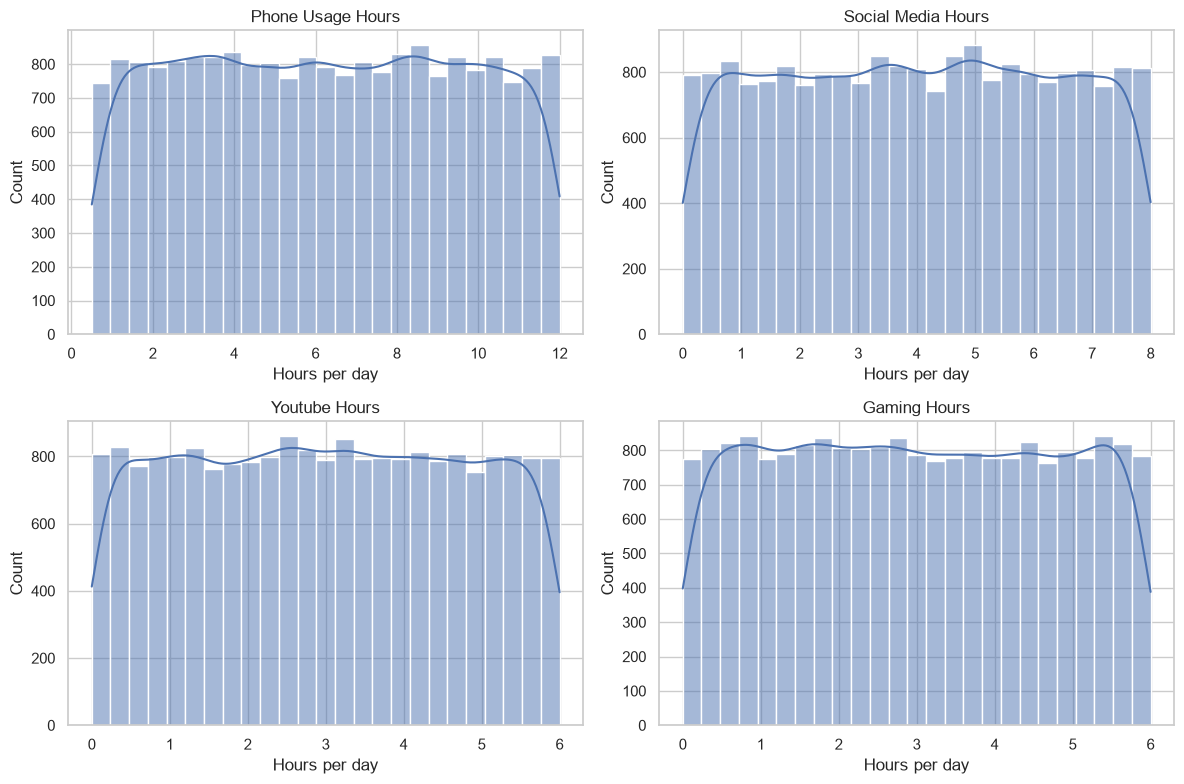

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' not in globals():
    df = pd.read_csv("student_productivity_distraction.csv")

digital_vars = [
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), digital_vars):
    sns.histplot(df[column], kde=True, bins=25, ax=ax)
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("Hours per day")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


## 6. Phone Usage vs Sleep

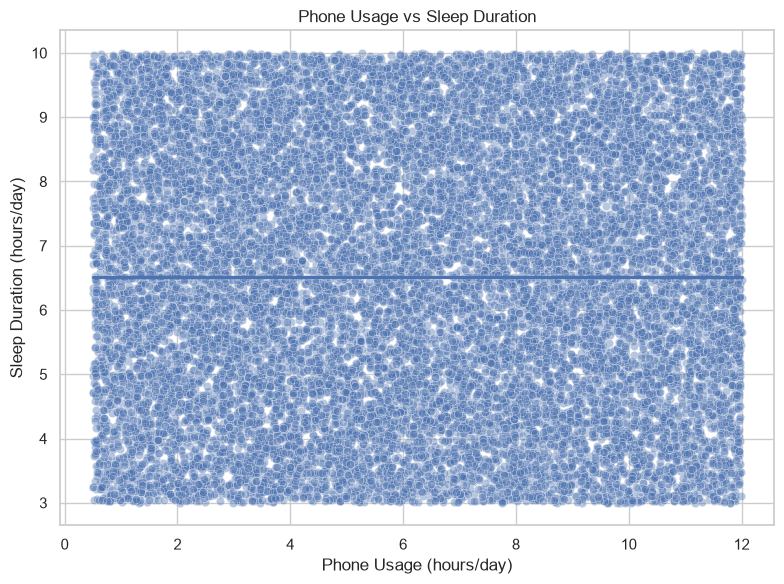

Correlation between Phone Usage and Sleep: 0.000


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' not in globals():
    df = pd.read_csv("student_productivity_distraction.csv")
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="phone_usage_hours",
    y="sleep_hours",
    alpha=0.4
)

sns.regplot(
    data=df,
    x="phone_usage_hours",
    y="sleep_hours",
    scatter=False
)

phone_sleep_corr = df["phone_usage_hours"].corr(df["sleep_hours"])

plt.title("Phone Usage vs Sleep Duration")
plt.xlabel("Phone Usage (hours/day)")
plt.ylabel("Sleep Duration (hours/day)")
plt.tight_layout()
plt.show()

print(f"Correlation between Phone Usage and Sleep: {phone_sleep_corr:.3f}")


## 7. Phone Usage vs Focus

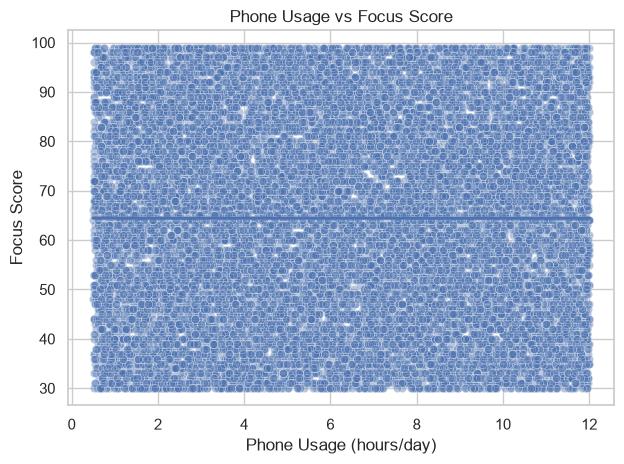

Correlation between Phone Usage and Focus: -0.000


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' not in globals():
    df = pd.read_csv("student_productivity_distraction.csv")
    plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="phone_usage_hours",
    y="focus_score",
    alpha=0.4
)

sns.regplot(
    data=df,
    x="phone_usage_hours",
    y="focus_score",
    scatter=False
)

phone_focus_corr = df["phone_usage_hours"].corr(df["focus_score"])

plt.title("Phone Usage vs Focus Score")
plt.xlabel("Phone Usage (hours/day)")
plt.ylabel("Focus Score")
plt.tight_layout()
plt.show()

print(f"Correlation between Phone Usage and Focus: {phone_focus_corr:.3f}")


## 8. Correlation Analysis

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' not in globals():
    df = pd.read_csv("student_productivity_distraction.csv")
correlation_matrix = df.corr(numeric_only=True)

productivity_corr = (
    correlation_matrix["productivity_score"]
    .sort_values(ascending=False)
)

print("Correlation with Productivity Score:")
display(productivity_corr)


Correlation with Productivity Score:


productivity_score       1.0000
study_hours_per_day      0.7328
focus_score              0.4114
sleep_hours              0.3409
attendance_percentage    0.1761
student_id               0.0126
coffee_intake_mg         0.0102
exercise_minutes         0.0029
final_grade              0.0020
social_media_hours       0.0013
gaming_hours             0.0007
youtube_hours           -0.0002
assignments_completed   -0.0018
age                     -0.0054
breaks_per_day          -0.0058
stress_level            -0.1971
phone_usage_hours       -0.3267
Name: productivity_score, dtype: float64

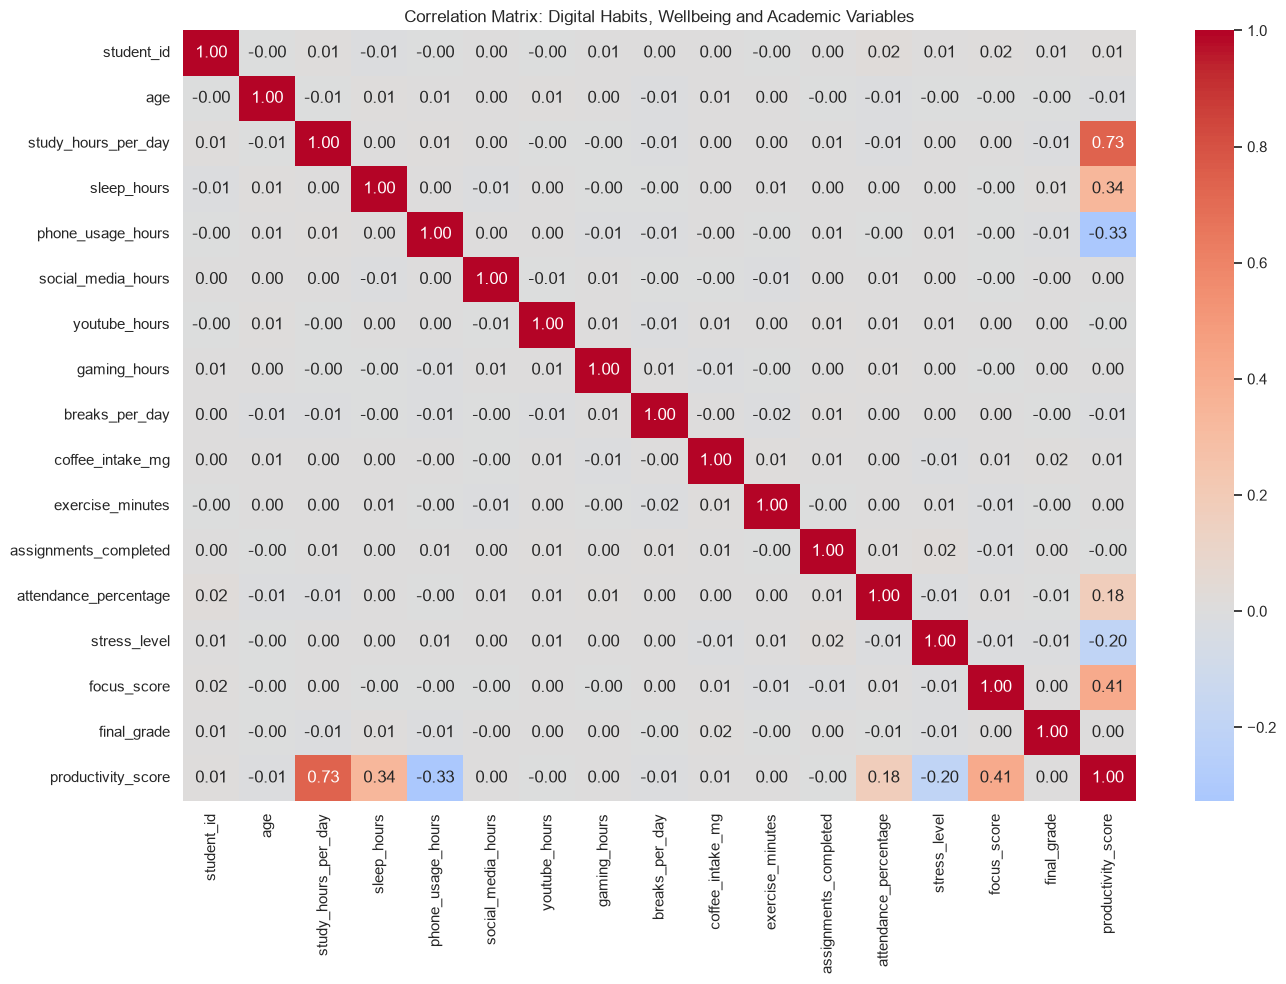

In [9]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix: Digital Habits, Wellbeing and Academic Variables")
plt.tight_layout()
plt.show()


### Main productivity correlations

The strongest linear associations with `productivity_score` in this dataset are:

- `study_hours_per_day`: **+0.73**
- `focus_score`: **+0.41**
- `sleep_hours`: **+0.34**
- `phone_usage_hours`: **−0.33**
- `stress_level`: **−0.20**
- `attendance_percentage`: **+0.18**

Social media, YouTube and gaming hours show negligible linear associations with productivity.


## 9. Productivity Group Analysis

In [10]:
df["productivity_group"] = pd.qcut(
    df["productivity_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

group_summary = df.groupby(
    "productivity_group",
    observed=True
)[
    [
        "study_hours_per_day",
        "sleep_hours",
        "phone_usage_hours",
        "social_media_hours",
        "gaming_hours",
        "exercise_minutes",
        "stress_level",
        "focus_score",
        "attendance_percentage"
    ]
].mean()

display(group_summary.round(2))


,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,gaming_hours,exercise_minutes,stress_level,focus_score,attendance_percentage
productivity_group,,,,,,,,,
Low,2.9200,5.7900,7.4000,4.0000,2.9800,59.6600,6.0900,55.7800,66.7500
Medium,5.2700,6.5300,6.2600,3.9800,3.0100,59.4000,5.4200,64.2200,70.0400
High,7.5700,7.2400,5.1000,4.0300,2.9800,59.8800,4.9300,73.3400,73.0500


### Digital behavior across productivity groups

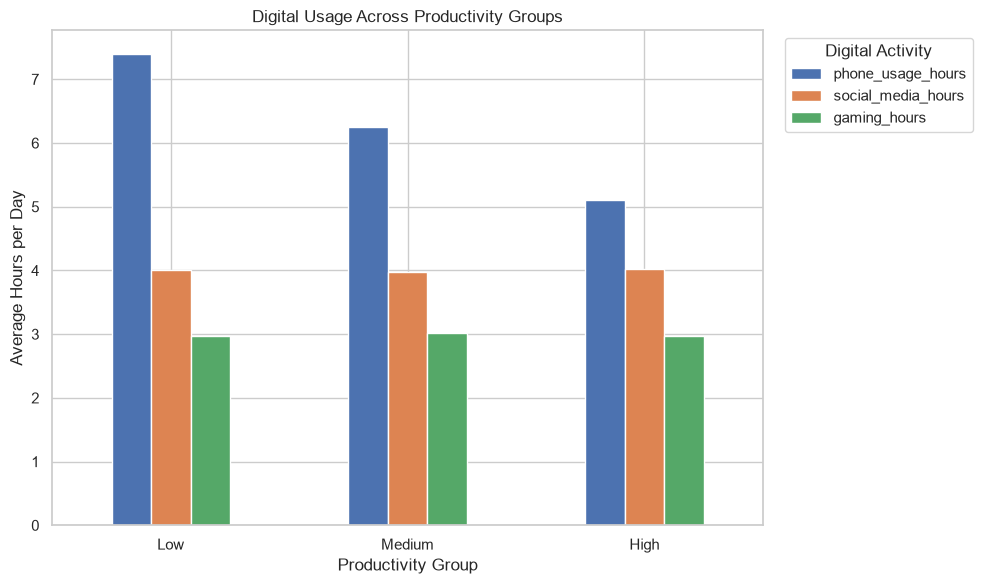

In [11]:
digital_group = group_summary[
    ["phone_usage_hours", "social_media_hours", "gaming_hours"]
]

digital_group.plot(kind="bar", figsize=(10, 6))

plt.title("Digital Usage Across Productivity Groups")
plt.xlabel("Productivity Group")
plt.ylabel("Average Hours per Day")
plt.xticks(rotation=0)
plt.legend(title="Digital Activity", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Wellbeing across productivity groups

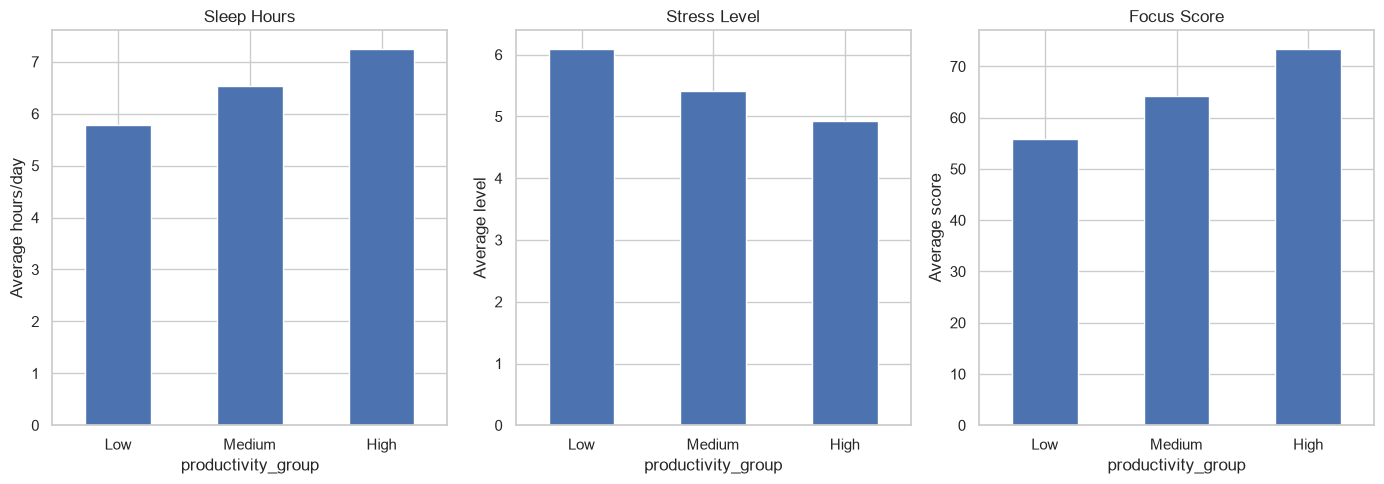

In [12]:
# Plot separately because the variables use different scales.
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

group_summary["sleep_hours"].plot(kind="bar", ax=axes[0], title="Sleep Hours")
axes[0].set_ylabel("Average hours/day")
axes[0].tick_params(axis="x", rotation=0)

group_summary["stress_level"].plot(kind="bar", ax=axes[1], title="Stress Level")
axes[1].set_ylabel("Average level")
axes[1].tick_params(axis="x", rotation=0)

group_summary["focus_score"].plot(kind="bar", ax=axes[2], title="Focus Score")
axes[2].set_ylabel("Average score")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### Academic behavior across productivity groups

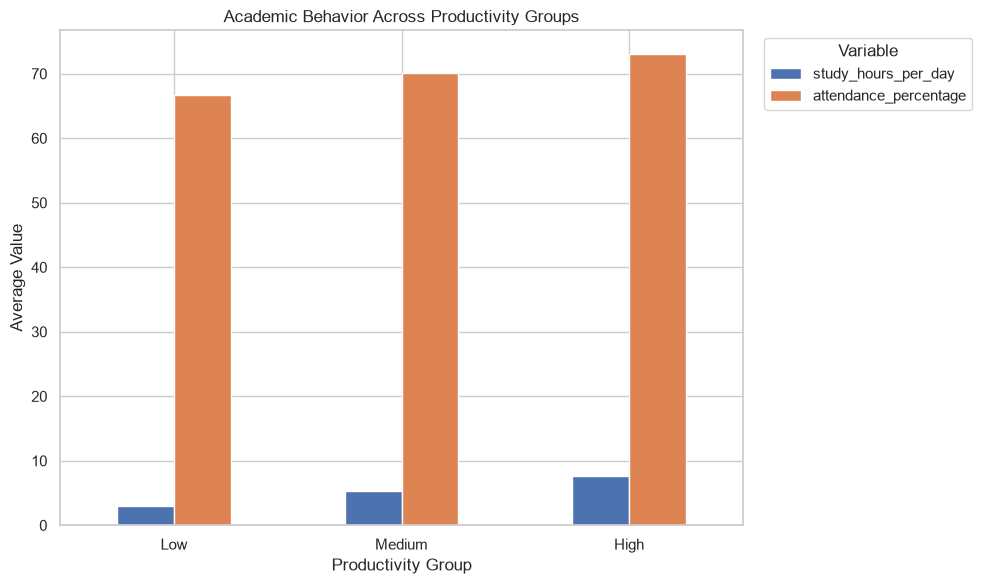

In [13]:
academic_group = group_summary[
    ["study_hours_per_day", "attendance_percentage"]
]

academic_group.plot(kind="bar", figsize=(10, 6))

plt.title("Academic Behavior Across Productivity Groups")
plt.xlabel("Productivity Group")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Variable", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Productivity-group interpretation

The average profiles show a clear progression from Low to High productivity:

- Study hours: **2.92 → 5.27 → 7.57**
- Sleep hours: **5.79 → 6.53 → 7.24**
- Phone usage: **7.40 → 6.26 → 5.10**
- Stress level: **6.09 → 5.42 → 4.93**
- Focus score: **55.78 → 64.22 → 73.34**
- Attendance: **66.75 → 70.04 → 73.05**

Social media and gaming averages remain close across the three groups, while exercise also changes very little.


## 10. Digital Activities vs Productivity

In [14]:
digital_columns = [
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours"
]

digital_productivity_corr = pd.Series({
    column: df[column].corr(df["productivity_score"])
    for column in digital_columns
}).sort_values()

display(digital_productivity_corr)


phone_usage_hours    -0.3267
youtube_hours        -0.0002
gaming_hours          0.0007
social_media_hours    0.0013
dtype: float64

### Interpretation

Among the digital-behavior variables, phone usage has the clearest negative linear association with productivity (**−0.327**). Social media, YouTube and gaming hours are approximately uncorrelated with productivity in this dataset.

A combined "digital distraction index" was therefore **not** created by simply adding these variables, because the observed relationships are not similar enough to justify treating them as one common measure.


## 11. Final Grade Correlation Analysis

In [15]:
grade_corr = (
    df.corr(numeric_only=True)["final_grade"]
    .sort_values(ascending=False)
)

display(grade_corr)


final_grade              1.0000
coffee_intake_mg         0.0153
sleep_hours              0.0105
student_id               0.0070
focus_score              0.0046
assignments_completed    0.0039
gaming_hours             0.0025
productivity_score       0.0020
youtube_hours            0.0016
social_media_hours      -0.0001
age                     -0.0009
exercise_minutes        -0.0027
breaks_per_day          -0.0037
attendance_percentage   -0.0053
phone_usage_hours       -0.0121
study_hours_per_day     -0.0122
stress_level            -0.0122
Name: final_grade, dtype: float64

### Interpretation

The behavioral and productivity variables show very weak linear associations with `final_grade` in this dataset. In particular, `productivity_score` has a correlation of approximately **0.002** with final grade.

Therefore, this project does **not** claim that the measured productivity score predicts or causes higher academic grades.


## 12. Machine Learning — Productivity Prediction

A NumPy-based **Linear Regression** model is used because the local environment blocked the compiled scikit-learn extension. The model uses an 80/20 train-test split and standardized numerical predictors.

The target variable is `productivity_score`.


In [16]:
features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "social_media_hours",
    "youtube_hours",
    "gaming_hours",
    "breaks_per_day",
    "coffee_intake_mg",
    "exercise_minutes",
    "assignments_completed",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]

X = df[features].values
y = df["productivity_score"].values

np.random.seed(42)

indices = np.arange(len(df))
np.random.shuffle(indices)

split = int(0.80 * len(df))

train_indices = indices[:split]
test_indices = indices[split:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


In [17]:
# Standardize using training-set statistics only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

# Add intercept
X_train_scaled = np.column_stack(
    [np.ones(len(X_train_scaled)), X_train_scaled]
)

X_test_scaled = np.column_stack(
    [np.ones(len(X_test_scaled)), X_test_scaled]
)

# Train linear regression using least squares
coefficients = np.linalg.lstsq(
    X_train_scaled,
    y_train,
    rcond=None
)[0]

# Predictions
y_pred = X_test_scaled @ coefficients


In [18]:
mae = np.mean(np.abs(y_test - y_pred))

rmse = np.sqrt(
    np.mean((y_test - y_pred) ** 2)
)

ss_res = np.sum(
    (y_test - y_pred) ** 2
)

ss_total = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

r2 = 1 - (ss_res / ss_total)

print("=" * 50)
print("LINEAR REGRESSION RESULTS")
print("=" * 50)
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")


LINEAR REGRESSION RESULTS
MAE  : 0.003
RMSE : 0.003
R²   : 1.000


### Model result

The observed run produced:

- **MAE = 0.003**
- **RMSE = 0.003**
- **R² = 1.000**

This is an unusually strong result. It indicates that the model almost exactly reconstructs the supplied `productivity_score`.

Because the target is highly structured and is related to several of the same variables used as predictors, this performance should **not** be interpreted as evidence that real-world student productivity can be predicted perfectly. It is better described as successful reconstruction of the dataset's productivity measure.


## 13. Model Coefficients

STANDARDIZED MODEL COEFFICIENTS
study_hours_per_day           : 11.824479
sleep_hours                   : 5.494702
phone_usage_hours             : -5.358453
social_media_hours            : 0.000005
youtube_hours                 : 0.000032
gaming_hours                  : 0.000027
breaks_per_day                : 0.000003
coffee_intake_mg              : 0.000030
exercise_minutes              : 0.000028
assignments_completed         : -0.000032
attendance_percentage         : 2.817443
stress_level                  : -3.091847
focus_score                   : 6.546645


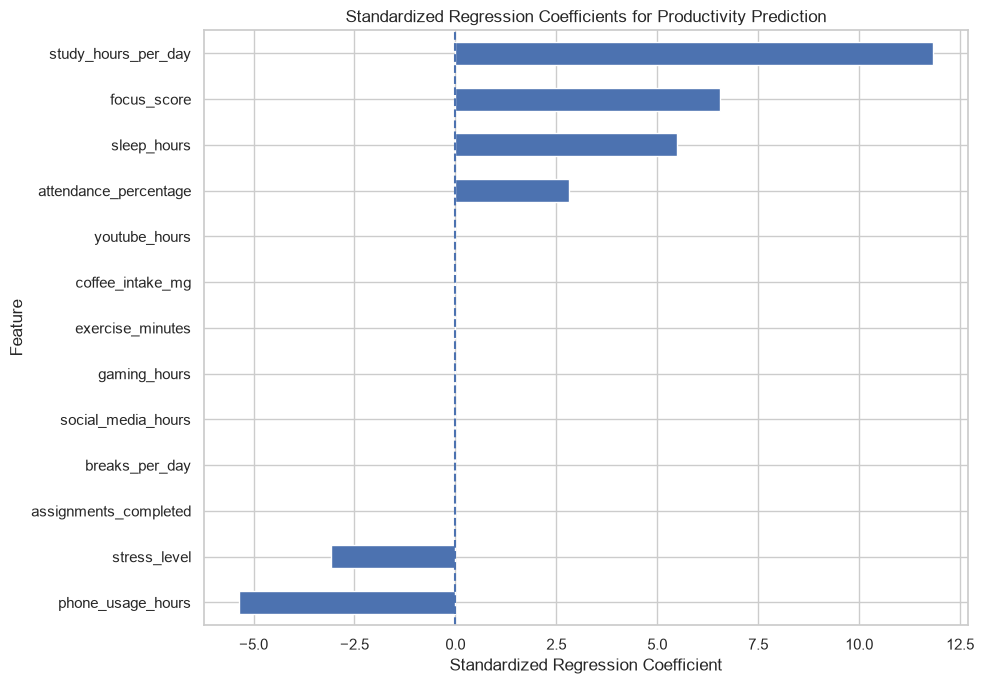

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'df' not in globals():
    df = pd.read_csv("student_productivity_distraction.csv")

if 'features' not in globals():
    features = [
        "study_hours_per_day",
        "sleep_hours",
        "phone_usage_hours",
        "social_media_hours",
        "youtube_hours",
        "gaming_hours",
        "breaks_per_day",
        "coffee_intake_mg",
        "exercise_minutes",
        "assignments_completed",
        "attendance_percentage",
        "stress_level",
        "focus_score"
    ]

if 'coefficients' not in globals():
    X = df[features].values
    y = df["productivity_score"].values

    np.random.seed(42)
    indices = np.arange(len(df))
    np.random.shuffle(indices)

    split = int(0.80 * len(df))
    train_indices = indices[:split]
    test_indices = indices[split:]

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std
    X_train_scaled = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
    X_test_scaled = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])

    coefficients = np.linalg.lstsq(X_train_scaled, y_train, rcond=None)[0]

print("=" * 50)
print("STANDARDIZED MODEL COEFFICIENTS")
print("=" * 50)

for feature, coefficient in zip(features, coefficients[1:]):
    print(f"{feature:30s}: {coefficient:.6f}")

feature_coefficients = coefficients[1:]

coefficient_series = pd.Series(
    feature_coefficients,
    index=features
).sort_values()

plt.figure(figsize=(10, 7))
coefficient_series.plot(kind="barh")

plt.xlabel("Standardized Regression Coefficient")
plt.ylabel("Feature")
plt.title("Standardized Regression Coefficients for Productivity Prediction")
plt.axvline(0, linestyle="--")

plt.tight_layout()
plt.show()


### Coefficient interpretation

The largest positive standardized coefficients are associated with:

- Study hours
- Focus score
- Sleep hours
- Attendance percentage

The largest negative coefficients are associated with:

- Phone usage
- Stress level

The coefficients for social media, YouTube, gaming, breaks, coffee, exercise and assignments are extremely close to zero in the fitted linear model.

These coefficients describe associations **within this fitted model**; they should not be interpreted as causal effects.


## 14. Actual vs Predicted Productivity

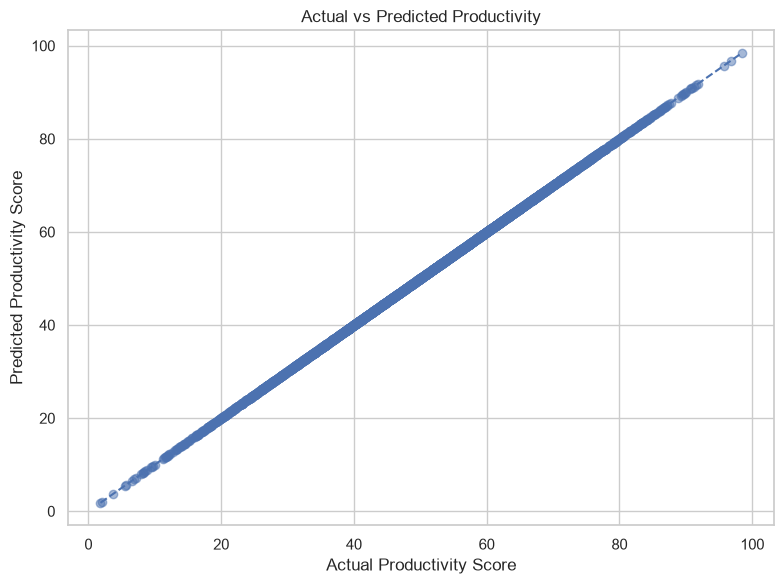

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'df' not in globals():
    df = pd.read_csv("student_productivity_distraction.csv")

if 'features' not in globals():
    features = [
        "study_hours_per_day",
        "sleep_hours",
        "phone_usage_hours",
        "social_media_hours",
        "youtube_hours",
        "gaming_hours",
        "breaks_per_day",
        "coffee_intake_mg",
        "exercise_minutes",
        "assignments_completed",
        "attendance_percentage",
        "stress_level",
        "focus_score"
    ]

if 'y_test' not in globals() or 'y_pred' not in globals():
    X = df[features].values
    y = df["productivity_score"].values

    np.random.seed(42)
    indices = np.arange(len(df))
    np.random.shuffle(indices)

    split = int(0.80 * len(df))
    train_indices = indices[:split]
    test_indices = indices[split:]

    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std
    X_train_scaled = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
    X_test_scaled = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])

    coefficients = np.linalg.lstsq(X_train_scaled, y_train, rcond=None)[0]
    y_pred = X_test_scaled @ coefficients

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.title("Actual vs Predicted Productivity")

plt.tight_layout()
plt.show()


## 15. Key Findings

### Key findings from the analysis

1. **Study hours** have the strongest linear association with the dataset's productivity score.
2. **Focus and sleep** are positively associated with productivity.
3. **Phone usage** has a moderate negative association with productivity.
4. **Stress** has a smaller negative association with productivity.
5. **Social media, YouTube and gaming** show negligible linear associations with productivity in this dataset.
6. High-productivity groups show higher average study hours, sleep, focus and attendance, and lower average phone usage and stress.
7. The measured behavioral/productivity variables have very weak linear relationships with **final grade** in this dataset.
8. The linear regression model reconstructs the supplied productivity score with near-zero error, indicating a highly structured target variable.


## 16. Limitations

- The analysis describes relationships in the supplied dataset and does not establish causation.
- The very high regression performance should be interpreted cautiously because the target appears strongly structured around the predictor variables.
- The analysis uses linear correlation and a linear regression model; nonlinear relationships may not be captured.
- The results should not be generalized to all students or real-world populations without validation on an independently collected dataset.


## 17. Conclusion

This project demonstrates an end-to-end data analytics workflow for examining digital habits, wellbeing and student productivity. Exploratory analysis identified study hours, focus, sleep, phone usage, stress and attendance as the main variables associated with the dataset's productivity score. Productivity-group comparisons reinforced these patterns, while final-grade analysis showed that the measured productivity score is not linearly related to final grade in the supplied data.

A NumPy-based linear regression model achieved near-perfect reconstruction of the productivity score. Rather than treating this as proof of perfect real-world prediction, the result highlights the highly structured nature of the target variable and provides a useful demonstration of regression modeling, evaluation and interpretation.


##ADVANCED ANALYSIS
## Target Forensics, Machine Learning, Feature Engineering, Classification and Explainable AI

In [21]:
## TARGET FORENSICS

Dataset loaded successfully!
Dataset shape: (20000, 18)
   student_id  age  gender  study_hours_per_day  sleep_hours  \
0           1   23  Female               4.3500       3.6300   
1           2   20    Male               6.1400       6.5800   
2           3   29  Female               4.9800       3.2600   
3           4   27  Female               3.1900       4.5800   
4           5   24    Male               7.6700       6.2100   

   phone_usage_hours  social_media_hours  youtube_hours  gaming_hours  \
0             3.3800              2.7300         1.8300        5.2600   
1             5.4800              1.5100         3.1300        1.7300   
2             4.8300              3.6300         0.1800        4.7100   
3            10.0600              3.9500         5.7500        2.5200   
4             3.0200              1.5900         5.4600        5.6500   

   breaks_per_day  coffee_intake_mg  exercise_minutes  assignments_completed  \
0               6               347     

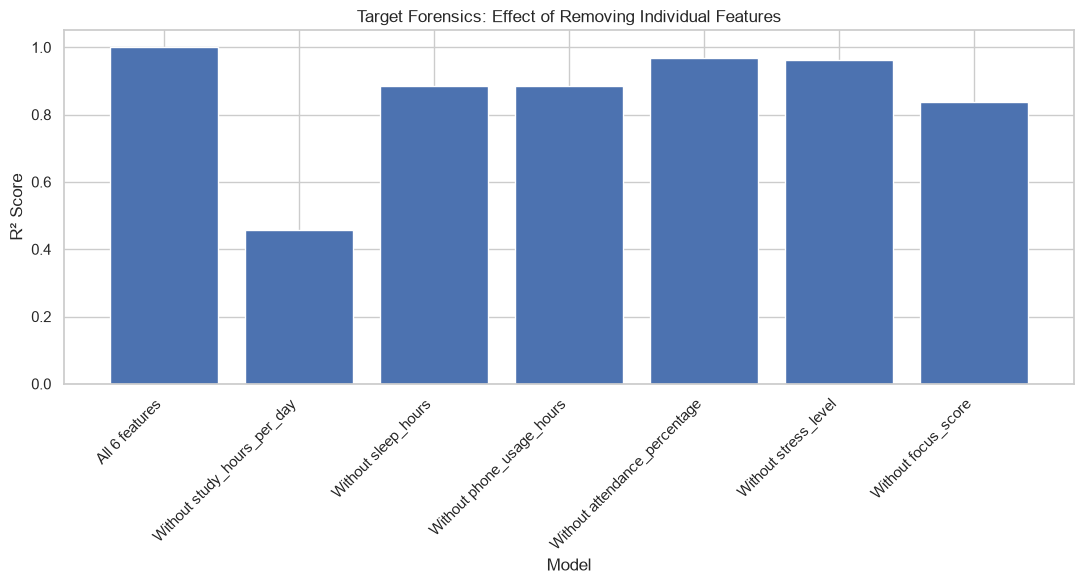


SUMMARY
Full model R²: 1.000000

R² change after removing each feature:
study_hours_per_day            R² = 0.457460 | R² Drop = 0.542540
sleep_hours                    R² = 0.885394 | R² Drop = 0.114606
phone_usage_hours              R² = 0.886352 | R² Drop = 0.113648
attendance_percentage          R² = 0.969373 | R² Drop = 0.030627
stress_level                   R² = 0.962922 | R² Drop = 0.037078
focus_score                    R² = 0.837717 | R² Drop = 0.162283

Target forensics completed successfully.


In [22]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS - V2
# TARGET FORENSICS
# ============================================================

# 1. IMPORT LIBRARIES
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_productivity_distraction.csv"


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print(df.head())


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

target = "productivity_score"

core_features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]

required_columns = core_features + [target]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("\nMissing columns:")
    print(missing_columns)
else:
    print("\nAll required columns are available.")


# ============================================================
# 4. TARGET FORENSICS
# ============================================================
#
# We first use all 6 important variables.
# Then we remove ONE variable at a time.
#
# If R² drops significantly after removing a variable,
# that variable contains important information about
# the supplied productivity_score.
# ============================================================

results = []


# ------------------------------------------------------------
# Model 1: All six variables
# ------------------------------------------------------------

feature_sets = {
    "All 6 features": core_features
}


# ------------------------------------------------------------
# Models: Remove one feature at a time
# ------------------------------------------------------------

for feature in core_features:

    remaining_features = [
        f for f in core_features
        if f != feature
    ]

    feature_sets[f"Without {feature}"] = remaining_features


# ============================================================
# 5. TRAIN AND EVALUATE MODELS
# ============================================================

for model_name, features in feature_sets.items():

    X = df[features]
    y = df[target]

    # 80% training / 20% testing
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    # Linear Regression
    model = LinearRegression()

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation
    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    results.append({
        "Model": model_name,
        "Features Used": len(features),
        "R2": r2,
        "RMSE": rmse
    })


# ============================================================
# 6. DISPLAY RESULTS
# ============================================================

results_df = pd.DataFrame(results)

print("\n==========================================")
print("TARGET FORENSICS RESULTS")
print("==========================================")

print(results_df.to_string(
    index=False,
    formatters={
        "R2": "{:.6f}".format,
        "RMSE": "{:.6f}".format
    }
))


# ============================================================
# 7. CALCULATE R² DROP
# ============================================================

full_model_r2 = results_df.loc[
    results_df["Model"] == "All 6 features",
    "R2"
].iloc[0]


for i in results_df.index:

    results_df.loc[i, "R2 Drop"] = (
        full_model_r2 - results_df.loc[i, "R2"]
    )


print("\n==========================================")
print("R² DROP AFTER REMOVING FEATURES")
print("==========================================")

print(results_df.to_string(
    index=False,
    formatters={
        "R2": "{:.6f}".format,
        "RMSE": "{:.6f}".format,
        "R2 Drop": "{:.6f}".format
    }
))


# ============================================================
# 8. VISUALIZE R²
# ============================================================

plt.figure(figsize=(11, 6))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title(
    "Target Forensics: Effect of Removing Individual Features"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(
    min(0, results_df["R2"].min() - 0.05),
    1.05
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. SUMMARY
# ============================================================

print("\n==========================================")
print("SUMMARY")
print("==========================================")

print(f"Full model R²: {full_model_r2:.6f}")

print("\nR² change after removing each feature:")

for feature in core_features:

    model_name = f"Without {feature}"

    row = results_df[
        results_df["Model"] == model_name
    ].iloc[0]

    print(
        f"{feature:30s} "
        f"R² = {row['R2']:.6f} | "
        f"R² Drop = {row['R2 Drop']:.6f}"
    )

print("\nTarget forensics completed successfully.")

TARGET STRUCTURE ANALYSIS
R²   : 0.9999999682
MAE  : 0.0024870393
RMSE : 0.0028690175

LINEAR MODEL COEFFICIENTS
              Feature Coefficient Absolute Effect
  study_hours_per_day    4.316387        4.316387
          sleep_hours    2.697748        2.697748
    phone_usage_hours   -1.618637        1.618637
         stress_level   -1.079097        1.079097
          focus_score    0.323729        0.323729
attendance_percentage    0.161864        0.161864

Intercept:
-6.238755

APPROXIMATE PRODUCTIVITY SCORE EQUATION
Productivity Score ≈ -6.2388 + 4.3164 × study_hours_per_day + 2.6977 × sleep_hours - 1.6186 × phone_usage_hours + 0.1619 × attendance_percentage - 1.0791 × stress_level + 0.3237 × focus_score


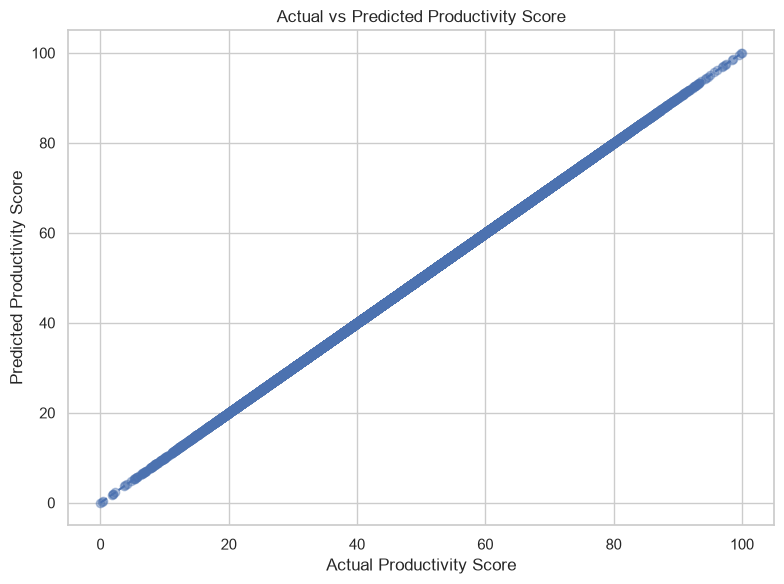


RESIDUAL ANALYSIS
Mean Residual : 0.0000000000
Maximum Absolute Residual : 0.0050850366
Minimum Residual : -0.0050850366
Maximum Residual : 0.0050645143


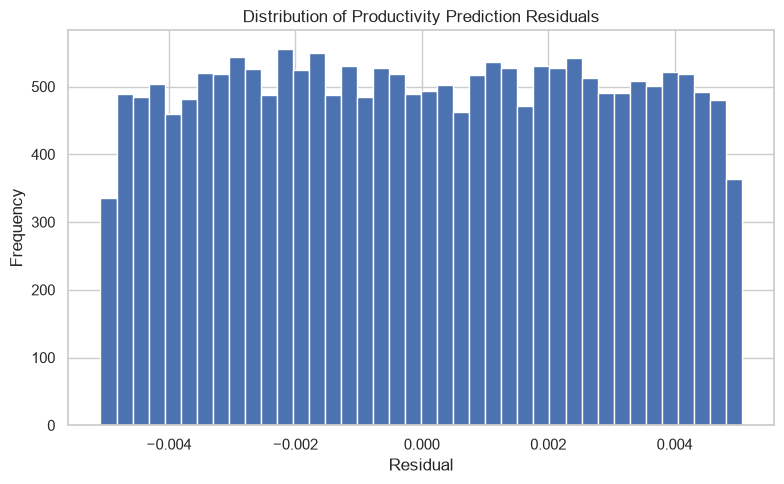


V2 TARGET FORENSICS SUMMARY
The six selected behavioral variables were used to reconstruct the supplied productivity score.

R² = 1.000000
RMSE = 0.002869

The coefficients show the direction and magnitude of the linear association learned from the dataset.

Important: these coefficients describe the structure of this dataset. They do NOT prove that changing a student's behavior will cause productivity to change.


In [23]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS 
# STEP 2: TARGET STRUCTURE ANALYSIS
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_productivity_distraction.csv"

df = pd.read_csv(DATA_PATH)


# ============================================================
# 1. DEFINE FEATURES AND TARGET
# ============================================================

target = "productivity_score"

features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]


# ============================================================
# 2. PREPARE DATA
# ============================================================

X = df[features]
y = df[target]


# ============================================================
# 3. FIT LINEAR MODEL USING ALL DATA
# ============================================================

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)


# ============================================================
# 4. MODEL PERFORMANCE
# ============================================================

r2 = r2_score(y, y_pred)

mae = mean_absolute_error(y, y_pred)

rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)


print("==============================================")
print("TARGET STRUCTURE ANALYSIS")
print("==============================================")

print(f"R²   : {r2:.10f}")
print(f"MAE  : {mae:.10f}")
print(f"RMSE : {rmse:.10f}")


# ============================================================
# 5. MODEL COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients["Absolute Effect"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute Effect",
    ascending=False
)


print("\n==============================================")
print("LINEAR MODEL COEFFICIENTS")
print("==============================================")

print(coefficients.to_string(
    index=False,
    formatters={
        "Coefficient": "{:.6f}".format,
        "Absolute Effect": "{:.6f}".format
    }
))


# ============================================================
# 6. INTERCEPT
# ============================================================

print("\nIntercept:")
print(f"{model.intercept_:.6f}")


# ============================================================
# 7. FORMULA-LIKE REPRESENTATION
# ============================================================

print("\n==============================================")
print("APPROXIMATE PRODUCTIVITY SCORE EQUATION")
print("==============================================")

equation = f"Productivity Score ≈ {model.intercept_:.4f}"

for feature, coefficient in zip(
    features,
    model.coef_
):

    sign = "+" if coefficient >= 0 else "-"

    equation += (
        f" {sign} "
        f"{abs(coefficient):.4f} × {feature}"
    )

print(equation)


# ============================================================
# 8. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y,
    y_pred,
    alpha=0.4
)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")

plt.title(
    "Actual vs Predicted Productivity Score"
)

# Perfect prediction line
min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. RESIDUAL ANALYSIS
# ============================================================

residuals = y - y_pred

print("\n==============================================")
print("RESIDUAL ANALYSIS")
print("==============================================")

print(
    f"Mean Residual : {residuals.mean():.10f}"
)

print(
    f"Maximum Absolute Residual : "
    f"{np.abs(residuals).max():.10f}"
)

print(
    f"Minimum Residual : "
    f"{residuals.min():.10f}"
)

print(
    f"Maximum Residual : "
    f"{residuals.max():.10f}"
)


# ============================================================
# 10. RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Productivity Prediction Residuals"
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. SUMMARY
# ============================================================

print("\n==============================================")
print("V2 TARGET FORENSICS SUMMARY")
print("==============================================")

print(
    "The six selected behavioral variables were used "
    "to reconstruct the supplied productivity score."
)

print(
    f"\nR² = {r2:.6f}"
)

print(
    f"RMSE = {rmse:.6f}"
)

print(
    "\nThe coefficients show the direction and magnitude "
    "of the linear association learned from the dataset."
)

print(
    "\nImportant: these coefficients describe the structure "
    "of this dataset. They do NOT prove that changing a "
    "student's behavior will cause productivity to change."
)

LEARNED LINEAR MODEL
Intercept: -6.2387546132
study_hours_per_day           : 4.3163867963
sleep_hours                   : 2.6977479679
phone_usage_hours             : -1.6186366252
attendance_percentage         : 0.1618635303
stress_level                  : -1.0790967150
focus_score                   : 0.3237288000

RELATIVE COEFFICIENT WEIGHTS
              Feature Coefficient Relative Weight
  study_hours_per_day    4.316387       26.666827
          sleep_hours    2.697748       16.666805
    phone_usage_hours   -1.618637      -10.000008
attendance_percentage    0.161864        1.000000
         stress_level   -1.079097       -6.666707
          focus_score    0.323729        2.000011

WEIGHT PATTERN COMPARISON
              Feature Learned Relative Weight Expected Weight  Difference
  study_hours_per_day             26.66682722     26.66666667  0.00016055
          sleep_hours             16.66680544     16.66666667  0.00013878
    phone_usage_hours            -10.00000817    -10.

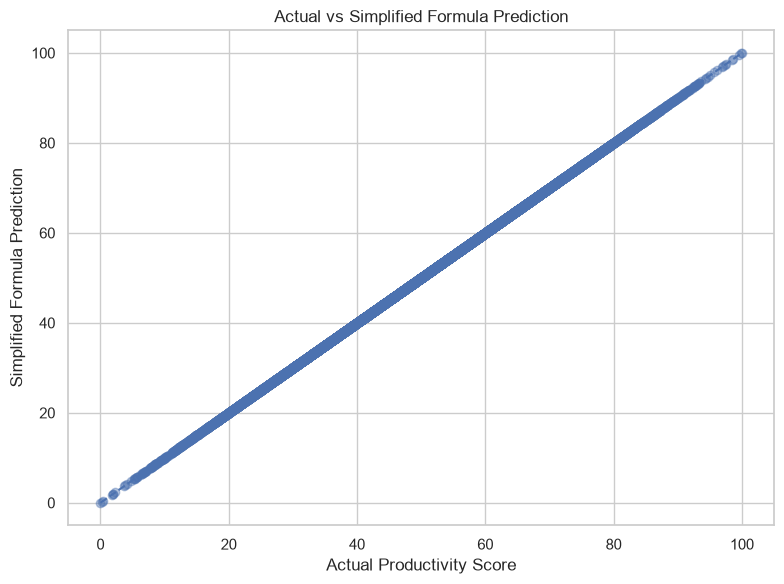


FINAL INTERPRETATION
The simplified weight structure reproduces the supplied productivity score extremely closely.

This provides strong evidence that the target variable has a highly structured linear relationship with the six selected variables.

Important: this analysis identifies mathematical structure in the supplied dataset. It does not prove that the dataset creator used this exact formula.


In [24]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS - V2
# STEP 3: HIDDEN FORMULA INVESTIGATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_productivity_distraction.csv"

df = pd.read_csv(DATA_PATH)

# ============================================================
# 1. DEFINE TARGET AND FEATURES
# ============================================================

target = "productivity_score"

features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]


# ============================================================
# 2. FIT LINEAR MODEL
# ============================================================

X = df[features]
y = df[target]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)


# ============================================================
# 3. GET ORIGINAL COEFFICIENTS
# ============================================================

coefficients = pd.Series(
    model.coef_,
    index=features
)

intercept = model.intercept_


print("====================================================")
print("LEARNED LINEAR MODEL")
print("====================================================")

print(f"Intercept: {intercept:.10f}")

for feature in features:
    print(
        f"{feature:30s}: "
        f"{coefficients[feature]:.10f}"
    )


# ============================================================
# 4. FIND RELATIVE COEFFICIENT WEIGHTS
# ============================================================

attendance_coefficient = coefficients[
    "attendance_percentage"
]

relative_weights = coefficients / attendance_coefficient


relative_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": [
        coefficients[f] for f in features
    ],
    "Relative Weight": [
        relative_weights[f] for f in features
    ]
})


print("\n====================================================")
print("RELATIVE COEFFICIENT WEIGHTS")
print("====================================================")

print(relative_df.to_string(
    index=False,
    formatters={
        "Coefficient": "{:.6f}".format,
        "Relative Weight": "{:.6f}".format
    }
))


# ============================================================
# 5. COMPARE WITH SIMPLE FRACTION-LIKE WEIGHTS
# ============================================================
#
# Based on the learned coefficients, we test whether the
# relative weights approximately follow:
#
# Study       = 80/3  = 26.6667
# Sleep       = 50/3  = 16.6667
# Phone       = -10
# Attendance  = 1
# Stress      = -20/3 = -6.6667
# Focus       = 2
# ============================================================

expected_relative_weights = {
    "study_hours_per_day": 80 / 3,
    "sleep_hours": 50 / 3,
    "phone_usage_hours": -10,
    "attendance_percentage": 1,
    "stress_level": -20 / 3,
    "focus_score": 2
}


comparison = []

for feature in features:

    learned = relative_weights[feature]

    expected = expected_relative_weights[feature]

    difference = learned - expected

    comparison.append({
        "Feature": feature,
        "Learned Relative Weight": learned,
        "Expected Weight": expected,
        "Difference": difference
    })


comparison_df = pd.DataFrame(comparison)


print("\n====================================================")
print("WEIGHT PATTERN COMPARISON")
print("====================================================")

print(comparison_df.to_string(
    index=False,
    formatters={
        "Learned Relative Weight": "{:.8f}".format,
        "Expected Weight": "{:.8f}".format,
        "Difference": "{:.8f}".format
    }
))


# ============================================================
# 6. CREATE A SIMPLIFIED FORMULA
# ============================================================

# Use the attendance coefficient as the common scale.

k = attendance_coefficient

simplified_coefficients = {
    "study_hours_per_day": k * (80 / 3),
    "sleep_hours": k * (50 / 3),
    "phone_usage_hours": k * (-10),
    "attendance_percentage": k,
    "stress_level": k * (-20 / 3),
    "focus_score": k * 2
}


# ============================================================
# 7. CALCULATE PREDICTIONS USING SIMPLIFIED WEIGHTS
# ============================================================

simplified_prediction = (
    intercept
    + simplified_coefficients["study_hours_per_day"]
        * df["study_hours_per_day"]
    + simplified_coefficients["sleep_hours"]
        * df["sleep_hours"]
    + simplified_coefficients["phone_usage_hours"]
        * df["phone_usage_hours"]
    + simplified_coefficients["attendance_percentage"]
        * df["attendance_percentage"]
    + simplified_coefficients["stress_level"]
        * df["stress_level"]
    + simplified_coefficients["focus_score"]
        * df["focus_score"]
)


# ============================================================
# 8. EVALUATE SIMPLIFIED FORMULA
# ============================================================

simplified_r2 = r2_score(
    y,
    simplified_prediction
)

simplified_mae = mean_absolute_error(
    y,
    simplified_prediction
)

simplified_rmse = np.sqrt(
    mean_squared_error(
        y,
        simplified_prediction
    )
)


print("\n====================================================")
print("SIMPLIFIED FORMULA PERFORMANCE")
print("====================================================")

print(f"R²   : {simplified_r2:.10f}")
print(f"MAE  : {simplified_mae:.10f}")
print(f"RMSE : {simplified_rmse:.10f}")


# ============================================================
# 9. COMPARE ORIGINAL MODEL VS SIMPLIFIED FORMULA
# ============================================================

original_r2 = r2_score(y, y_pred)
original_mae = mean_absolute_error(y, y_pred)
original_rmse = np.sqrt(
    mean_squared_error(y, y_pred)
)


performance_comparison = pd.DataFrame({
    "Model": [
        "Learned Linear Regression",
        "Simplified Weight Formula"
    ],
    "R2": [
        original_r2,
        simplified_r2
    ],
    "MAE": [
        original_mae,
        simplified_mae
    ],
    "RMSE": [
        original_rmse,
        simplified_rmse
    ]
})


print("\n====================================================")
print("MODEL COMPARISON")
print("====================================================")

print(performance_comparison.to_string(
    index=False,
    formatters={
        "R2": "{:.10f}".format,
        "MAE": "{:.10f}".format,
        "RMSE": "{:.10f}".format
    }
))


# ============================================================
# 10. CALCULATE DIFFERENCE BETWEEN ACTUAL TARGET
#     AND SIMPLIFIED FORMULA
# ============================================================

formula_error = (
    y - simplified_prediction
)

print("\n====================================================")
print("FORMULA ERROR ANALYSIS")
print("====================================================")

print(
    f"Mean Error: "
    f"{formula_error.mean():.10f}"
)

print(
    f"Maximum Absolute Error: "
    f"{np.abs(formula_error).max():.10f}"
)

print(
    f"Median Absolute Error: "
    f"{np.median(np.abs(formula_error)):.10f}"
)


# ============================================================
# 11. DISPLAY SAMPLE COMPARISON
# ============================================================

sample_comparison = pd.DataFrame({
    "Actual Productivity": y.head(10).values,
    "Linear Model Prediction": y_pred[:10],
    "Simplified Formula Prediction": (
        simplified_prediction.head(10).values
    ),
    "Formula Error": (
        formula_error.head(10).values
    )
})


print("\n====================================================")
print("SAMPLE ACTUAL VS FORMULA PREDICTIONS")
print("====================================================")

print(sample_comparison.to_string(
    index=False,
    formatters={
        "Actual Productivity": "{:.6f}".format,
        "Linear Model Prediction": "{:.6f}".format,
        "Simplified Formula Prediction": "{:.6f}".format,
        "Formula Error": "{:.6f}".format
    }
))


# ============================================================
# 12. PRINT THE SIMPLIFIED EQUATION
# ============================================================

print("\n====================================================")
print("SIMPLIFIED PRODUCTIVITY EQUATION")
print("====================================================")

print(
    f"Productivity Score ≈ {intercept:.6f}"
)

print(
    f" + {simplified_coefficients['study_hours_per_day']:.6f}"
    " × study_hours_per_day"
)

print(
    f" + {simplified_coefficients['sleep_hours']:.6f}"
    " × sleep_hours"
)

print(
    f" {simplified_coefficients['phone_usage_hours']:+.6f}"
    " × phone_usage_hours"
)

print(
    f" {simplified_coefficients['attendance_percentage']:+.6f}"
    " × attendance_percentage"
)

print(
    f" {simplified_coefficients['stress_level']:+.6f}"
    " × stress_level"
)

print(
    f" {simplified_coefficients['focus_score']:+.6f}"
    " × focus_score"
)


# ============================================================
# 13. VISUALIZE FORMULA ACCURACY
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y,
    simplified_prediction,
    alpha=0.4
)

min_value = min(
    y.min(),
    simplified_prediction.min()
)

max_value = max(
    y.max(),
    simplified_prediction.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Simplified Formula Prediction")

plt.title(
    "Actual vs Simplified Formula Prediction"
)

plt.tight_layout()
plt.show()


# ============================================================
# 14. FINAL INTERPRETATION
# ============================================================

print("\n====================================================")
print("FINAL INTERPRETATION")
print("====================================================")

if simplified_r2 > 0.999:

    print(
        "The simplified weight structure reproduces the "
        "supplied productivity score extremely closely."
    )

    print(
        "\nThis provides strong evidence that the target "
        "variable has a highly structured linear relationship "
        "with the six selected variables."
    )

else:

    print(
        "The simplified weight structure does not fully "
        "reproduce the target."
    )

print(
    "\nImportant: this analysis identifies mathematical "
    "structure in the supplied dataset. It does not prove "
    "that the dataset creator used this exact formula."
)

Training: Linear Regression
Training: Ridge Regression
Training: Random Forest
Training: Gradient Boosting
Training: HistGradient Boosting

5-FOLD CROSS-VALIDATION
Linear Regression: Mean R² = 1.000000, Std = 0.000000
Ridge Regression: Mean R² = 1.000000, Std = 0.000000
Random Forest: Mean R² = 0.982750, Std = 0.000370
Gradient Boosting: Mean R² = 0.993137, Std = 0.000234
HistGradient Boosting: Mean R² = 0.996501, Std = 0.000078

MODEL BENCHMARK RESULTS
                Model  Test R² Test MAE Test RMSE CV R² Mean CV R² Std
    Linear Regression 1.000000 0.002484  0.002874   1.000000  0.000000
     Ridge Regression 1.000000 0.002605  0.003063   1.000000  0.000000
        Random Forest 0.982744 1.647887  2.108304   0.982750  0.000370
    Gradient Boosting 0.993224 1.040231  1.321107   0.993137  0.000234
HistGradient Boosting 0.996390 0.761361  0.964293   0.996501  0.000078

RANKED MODEL RESULTS
                Model  Test R² Test MAE Test RMSE CV R² Mean CV R² Std
    Linear Regression 1

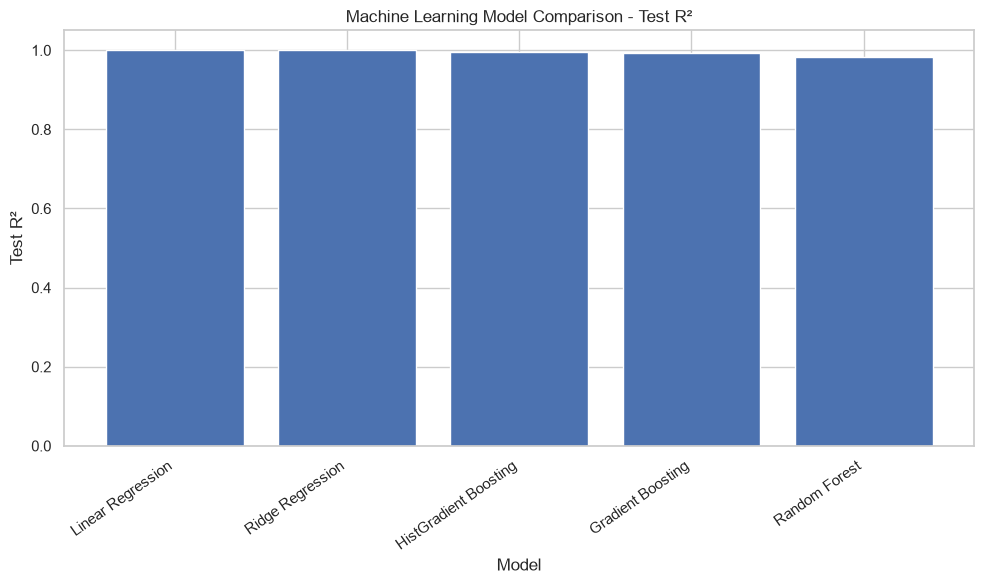

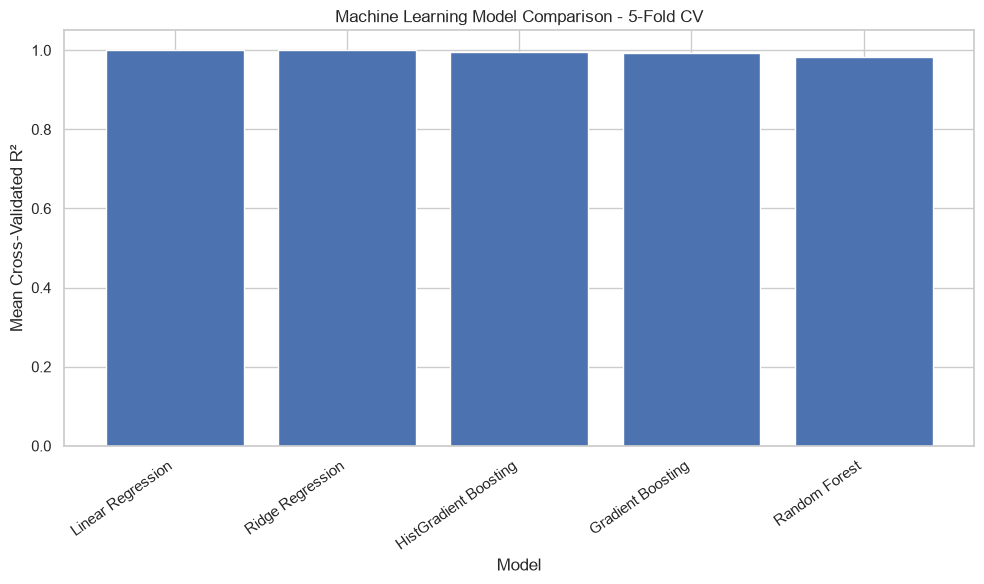

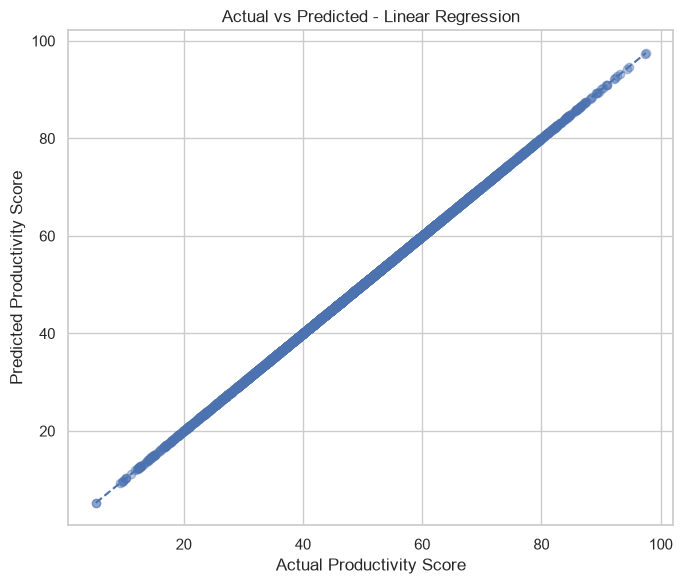

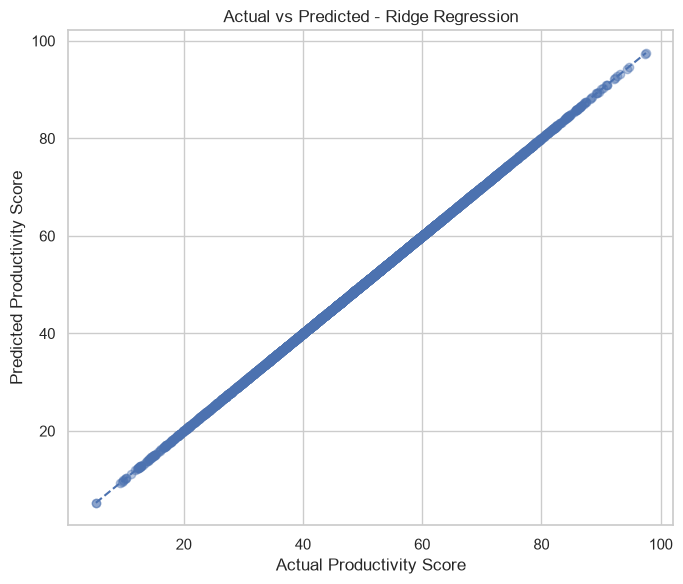

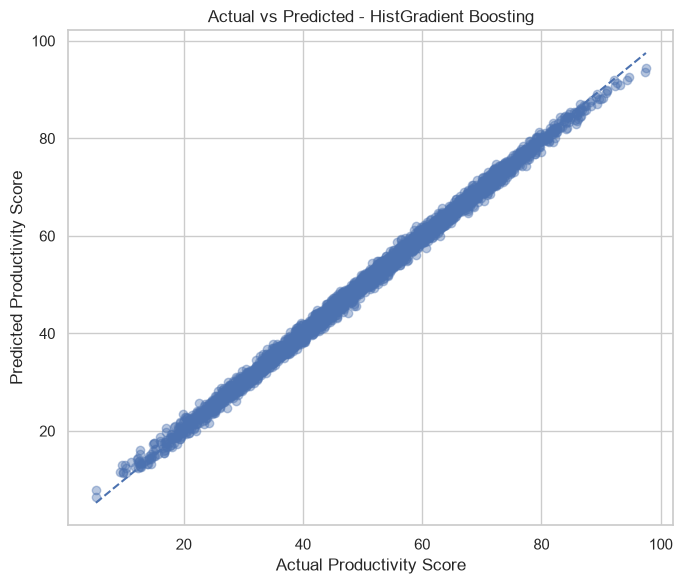

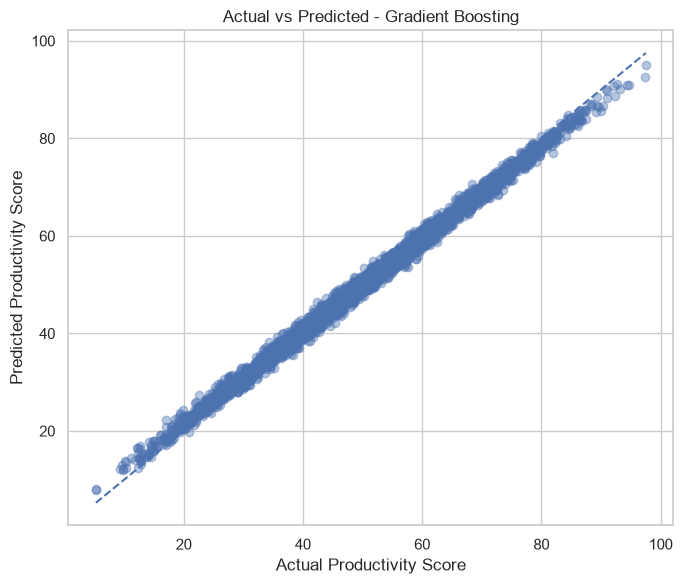

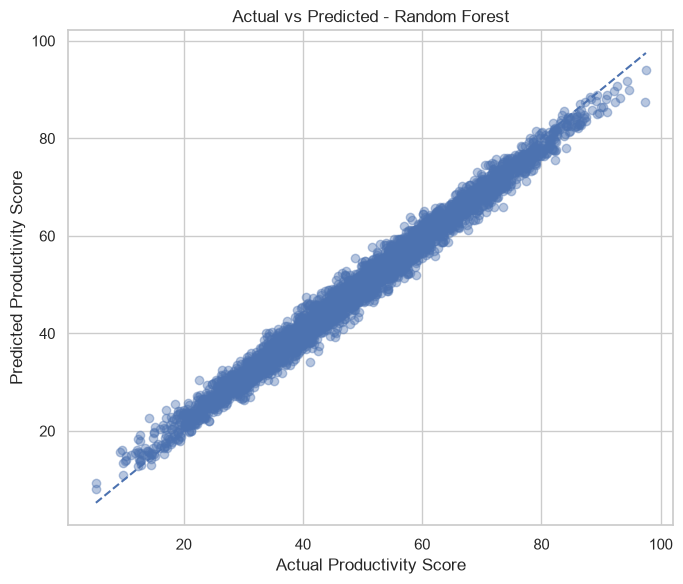


V2 MACHINE LEARNING SUMMARY
Five regression models were evaluated using an 80/20 train-test split and 5-fold cross-validation.

The purpose is not simply to maximize R².
We are checking whether more complex nonlinear models provide meaningful improvement over the simple linear structure discovered during target forensics.

Benchmark completed successfully.


In [25]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS - V2
# STEP 4: MACHINE LEARNING MODEL BENCHMARK
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df = pd.read_csv("student_productivity_distraction.csv")


# ============================================================
# 1. DEFINE FEATURES AND TARGET
# ============================================================

target = "productivity_score"

features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]

X = df[features]
y = df[target]


# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 3. DEFINE MODELS
# ============================================================

models = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}


# ============================================================
# 4. TRAIN AND EVALUATE MODELS
# ============================================================

results = []

predictions = {}

for model_name, model in models.items():

    print(f"Training: {model_name}")

    # Train
    model.fit(X_train, y_train)

    # Test prediction
    y_pred = model.predict(X_test)

    predictions[model_name] = y_pred

    # Metrics
    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    results.append({
        "Model": model_name,
        "Test R²": r2,
        "Test MAE": mae,
        "Test RMSE": rmse
    })


# ============================================================
# 5. CROSS-VALIDATION
# ============================================================

print("\n==============================================")
print("5-FOLD CROSS-VALIDATION")
print("==============================================")

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV R² Mean": scores.mean(),
        "CV R² Std": scores.std()
    })

    print(
        f"{model_name}: "
        f"Mean R² = {scores.mean():.6f}, "
        f"Std = {scores.std():.6f}"
    )


# ============================================================
# 6. COMBINE RESULTS
# ============================================================

test_results_df = pd.DataFrame(results)

cv_results_df = pd.DataFrame(cv_results)

final_results = test_results_df.merge(
    cv_results_df,
    on="Model"
)


print("\n==============================================")
print("MODEL BENCHMARK RESULTS")
print("==============================================")

print(final_results.to_string(
    index=False,
    formatters={
        "Test R²": "{:.6f}".format,
        "Test MAE": "{:.6f}".format,
        "Test RMSE": "{:.6f}".format,
        "CV R² Mean": "{:.6f}".format,
        "CV R² Std": "{:.6f}".format
    }
))


# ============================================================
# 7. SORT BY CROSS-VALIDATED R²
# ============================================================

final_results = final_results.sort_values(
    by="CV R² Mean",
    ascending=False
).reset_index(drop=True)


print("\n==============================================")
print("RANKED MODEL RESULTS")
print("==============================================")

print(final_results.to_string(
    index=False,
    formatters={
        "Test R²": "{:.6f}".format,
        "Test MAE": "{:.6f}".format,
        "Test RMSE": "{:.6f}".format,
        "CV R² Mean": "{:.6f}".format,
        "CV R² Std": "{:.6f}".format
    }
))


# ============================================================
# 8. TEST R² COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["Test R²"]
)

plt.ylabel("Test R²")
plt.xlabel("Model")
plt.title(
    "Machine Learning Model Comparison - Test R²"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(
    min(0, final_results["Test R²"].min() - 0.05),
    1.05
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. CROSS-VALIDATION R² COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["CV R² Mean"]
)

plt.ylabel("Mean Cross-Validated R²")
plt.xlabel("Model")
plt.title(
    "Machine Learning Model Comparison - 5-Fold CV"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(
    min(0, final_results["CV R² Mean"].min() - 0.05),
    1.05
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. ACTUAL VS PREDICTED FOR EACH MODEL
# ============================================================

for model_name in final_results["Model"]:

    y_pred = predictions[model_name]

    plt.figure(figsize=(7, 6))

    plt.scatter(
        y_test,
        y_pred,
        alpha=0.4
    )

    min_value = min(
        y_test.min(),
        y_pred.min()
    )

    max_value = max(
        y_test.max(),
        y_pred.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual Productivity Score")
    plt.ylabel("Predicted Productivity Score")

    plt.title(
        f"Actual vs Predicted - {model_name}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

print("\n==============================================")
print("V2 MACHINE LEARNING SUMMARY")
print("==============================================")

print(
    "Five regression models were evaluated using "
    "an 80/20 train-test split and 5-fold cross-validation."
)

print(
    "\nThe purpose is not simply to maximize R²."
)

print(
    "We are checking whether more complex nonlinear "
    "models provide meaningful improvement over the "
    "simple linear structure discovered during target forensics."
)

print("\nBenchmark completed successfully.")

ENGINEERED FEATURES
 phone_to_study_ratio  study_to_phone_ratio  focus_per_study_hour  sleep_study_balance  digital_wellbeing_balance  study_focus_index
               0.7596                1.2500               12.8090              -0.7200                     1.6710           247.9500
               0.8782                1.1004                7.8526               0.4400                     5.1270           300.8600
               0.9508                1.0101                7.4803              -1.7200                     6.5440           189.2400
               3.0578                0.3140               15.1976               1.3900                    -2.4290           159.5000
               0.3887                2.4583                5.2767              -1.4600                     5.8430           314.4700

ENGINEERED FEATURE CORRELATION WITH PRODUCTIVITY
                          Correlation with Productivity
study_focus_index                                0.8101
digital_wellbeing_ba

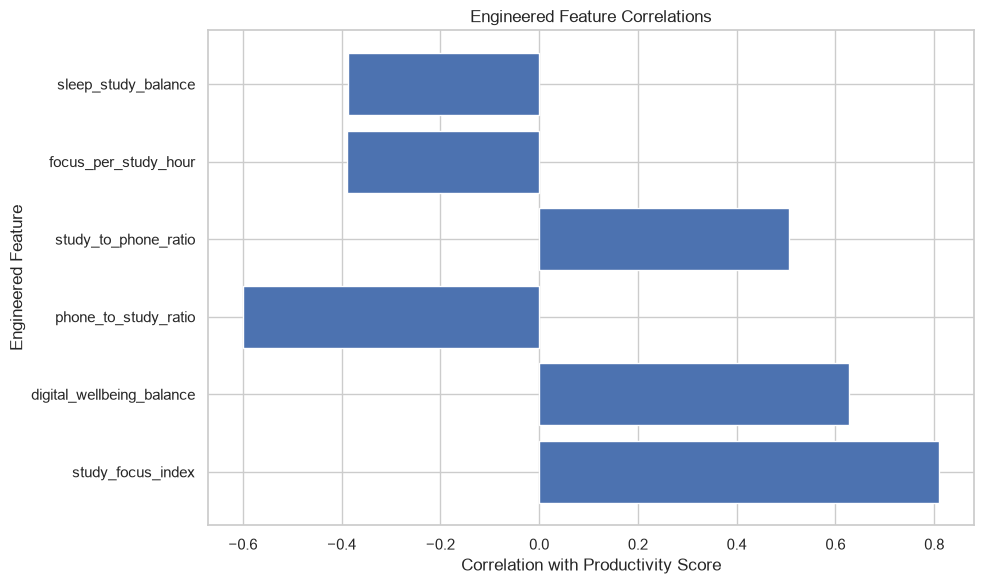

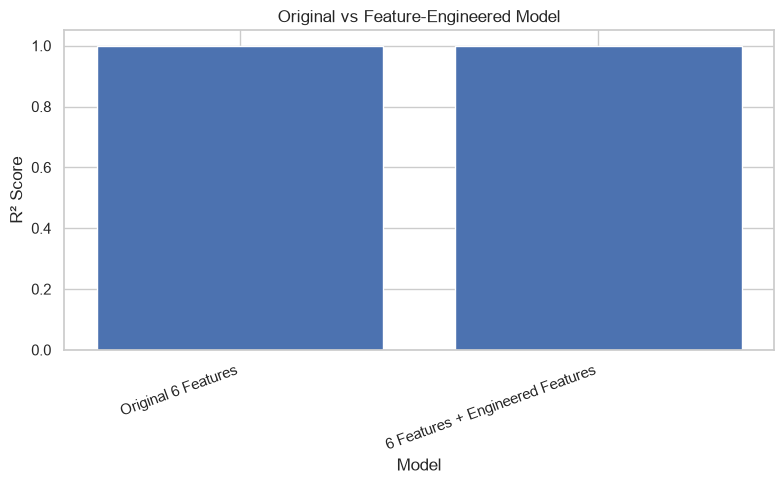


FEATURE ENGINEERING INTERPRETATION
Feature engineering produced virtually no change in predictive performance.

This is expected because the original six variables already reconstruct the supplied productivity score almost perfectly.

The engineered variables should therefore be evaluated based on interpretability and usefulness, not simply on whether they increase R².

Feature engineering step completed successfully.


In [26]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS 
# STEP 5: FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df = pd.read_csv("student_productivity_distraction.csv")


# ============================================================
# 1. COPY ORIGINAL DATA
# ============================================================

df_v2 = df.copy()


# ============================================================
# 2. CREATE ENGINEERED FEATURES
# ============================================================

# ------------------------------------------------------------
# A. Digital distraction ratio
# ------------------------------------------------------------
# Measures phone usage relative to study time.
# Higher value = relatively more phone use compared with study.
# ------------------------------------------------------------

df_v2["phone_to_study_ratio"] = (
    df_v2["phone_usage_hours"] /
    (df_v2["study_hours_per_day"] + 0.1)
)


# ------------------------------------------------------------
# B. Study-to-phone ratio
# ------------------------------------------------------------
# Higher value = more study time relative to phone use.
# ------------------------------------------------------------

df_v2["study_to_phone_ratio"] = (
    df_v2["study_hours_per_day"] /
    (df_v2["phone_usage_hours"] + 0.1)
)


# ------------------------------------------------------------
# C. Focus per study hour
# ------------------------------------------------------------
# Represents focus relative to study time.
# ------------------------------------------------------------

df_v2["focus_per_study_hour"] = (
    df_v2["focus_score"] /
    (df_v2["study_hours_per_day"] + 0.1)
)


# ------------------------------------------------------------
# D. Sleep-study balance
# ------------------------------------------------------------
# Difference between sleep and study hours.
# ------------------------------------------------------------

df_v2["sleep_study_balance"] = (
    df_v2["sleep_hours"] -
    df_v2["study_hours_per_day"]
)


# ------------------------------------------------------------
# E. Digital wellbeing balance
# ------------------------------------------------------------
# Combines positive and negative behavioral indicators.
#
# Higher:
#   sleep + focus + attendance
#
# Lower:
#   phone usage + stress
# ------------------------------------------------------------

df_v2["digital_wellbeing_balance"] = (
    df_v2["sleep_hours"]
    + df_v2["focus_score"] / 10
    + df_v2["attendance_percentage"] / 10
    - df_v2["phone_usage_hours"]
    - df_v2["stress_level"]
)


# ------------------------------------------------------------
# F. Study-focus index
# ------------------------------------------------------------

df_v2["study_focus_index"] = (
    df_v2["study_hours_per_day"]
    * df_v2["focus_score"]
)


# ============================================================
# 3. CHECK ENGINEERED FEATURES
# ============================================================

engineered_features = [
    "phone_to_study_ratio",
    "study_to_phone_ratio",
    "focus_per_study_hour",
    "sleep_study_balance",
    "digital_wellbeing_balance",
    "study_focus_index"
]

print("==============================================")
print("ENGINEERED FEATURES")
print("==============================================")

print(df_v2[
    engineered_features
].head().to_string(index=False))


# ============================================================
# 4. CHECK CORRELATION WITH PRODUCTIVITY
# ============================================================

correlations = (
    df_v2[
        engineered_features + ["productivity_score"]
    ]
    .corr()["productivity_score"]
    .drop("productivity_score")
    .sort_values(
        key=abs,
        ascending=False
    )
)


print("\n==============================================")
print("ENGINEERED FEATURE CORRELATION WITH PRODUCTIVITY")
print("==============================================")

print(correlations.to_frame(
    "Correlation with Productivity"
).to_string(
    formatters={
        "Correlation with Productivity": "{:.4f}".format
    }
))


# ============================================================
# 5. ORIGINAL MODEL
# ============================================================

original_features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]


X_original = df_v2[
    original_features
]

y = df_v2[
    "productivity_score"
]


X_train_original, X_test_original, y_train, y_test = (
    train_test_split(
        X_original,
        y,
        test_size=0.20,
        random_state=42
    )
)


original_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


original_model.fit(
    X_train_original,
    y_train
)


original_prediction = original_model.predict(
    X_test_original
)


original_r2 = r2_score(
    y_test,
    original_prediction
)

original_mae = mean_absolute_error(
    y_test,
    original_prediction
)

original_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        original_prediction
    )
)


# ============================================================
# 6. FEATURE-ENGINEERED MODEL
# ============================================================

all_features = (
    original_features +
    engineered_features
)


X_engineered = df_v2[
    all_features
]


X_train_engineered, X_test_engineered, y_train2, y_test2 = (
    train_test_split(
        X_engineered,
        y,
        test_size=0.20,
        random_state=42
    )
)


engineered_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


engineered_model.fit(
    X_train_engineered,
    y_train2
)


engineered_prediction = engineered_model.predict(
    X_test_engineered
)


engineered_r2 = r2_score(
    y_test2,
    engineered_prediction
)

engineered_mae = mean_absolute_error(
    y_test2,
    engineered_prediction
)

engineered_rmse = np.sqrt(
    mean_squared_error(
        y_test2,
        engineered_prediction
    )
)


# ============================================================
# 7. COMPARE ORIGINAL VS ENGINEERED MODEL
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Original 6 Features",
        "6 Features + Engineered Features"
    ],

    "Number of Features": [
        len(original_features),
        len(all_features)
    ],

    "R²": [
        original_r2,
        engineered_r2
    ],

    "MAE": [
        original_mae,
        engineered_mae
    ],

    "RMSE": [
        original_rmse,
        engineered_rmse
    ]
})


print("\n==============================================")
print("FEATURE ENGINEERING MODEL COMPARISON")
print("==============================================")

print(comparison.to_string(
    index=False,
    formatters={
        "R²": "{:.10f}".format,
        "MAE": "{:.6f}".format,
        "RMSE": "{:.6f}".format
    }
))


# ============================================================
# 8. CALCULATE IMPROVEMENT
# ============================================================

r2_change = engineered_r2 - original_r2

rmse_change = engineered_rmse - original_rmse

mae_change = engineered_mae - original_mae


print("\n==============================================")
print("MODEL CHANGE")
print("==============================================")

print(
    f"R² change   : {r2_change:.10f}"
)

print(
    f"MAE change  : {mae_change:.10f}"
)

print(
    f"RMSE change : {rmse_change:.10f}"
)


# ============================================================
# 9. VISUALIZE CORRELATIONS
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    correlations.index,
    correlations.values
)

plt.xlabel(
    "Correlation with Productivity Score"
)

plt.ylabel(
    "Engineered Feature"
)

plt.title(
    "Engineered Feature Correlations"
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. VISUALIZE MODEL COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R²"]
)

plt.ylabel("R² Score")
plt.xlabel("Model")

plt.title(
    "Original vs Feature-Engineered Model"
)

plt.ylim(
    min(0, comparison["R²"].min() - 0.05),
    1.05
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. INTERPRETATION
# ============================================================

print("\n==============================================")
print("FEATURE ENGINEERING INTERPRETATION")
print("==============================================")

if abs(r2_change) < 0.0001:

    print(
        "Feature engineering produced virtually no "
        "change in predictive performance."
    )

    print(
        "\nThis is expected because the original six "
        "variables already reconstruct the supplied "
        "productivity score almost perfectly."
    )

elif r2_change > 0:

    print(
        "Feature engineering improved the model's R²."
    )

else:

    print(
        "Feature engineering reduced the model's R²."
    )

print(
    "\nThe engineered variables should therefore be "
    "evaluated based on interpretability and usefulness, "
    "not simply on whether they increase R²."
)

print(
    "\nFeature engineering step completed successfully."
)

PRODUCTIVITY CLASS DISTRIBUTION
                    Count Percentage
productivity_group                  
Low                  6672     33.36%
Medium               6664     33.32%
High                 6664     33.32%

Training: Logistic Regression

Training: Random Forest

Training: Gradient Boosting

Training: HistGradient Boosting

CLASSIFICATION MODEL RESULTS
                Model Accuracy Precision Recall F1 Score
  Logistic Regression   0.9975    0.9975 0.9975   0.9975
        Random Forest   0.9250    0.9259 0.9250   0.9253
    Gradient Boosting   0.9200    0.9226 0.9200   0.9207
HistGradient Boosting   0.9517    0.9525 0.9517   0.9520

Logistic Regression
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1334
      Medium       1.00      0.99      1.00      1333
        High       1.00      1.00      1.00      1333

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
wei

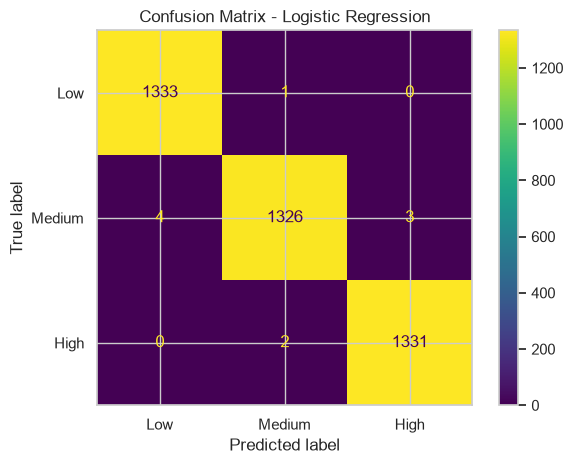


Confusion Matrix - Random Forest
[[1249   85    0]
 [  61 1206   66]
 [   0   88 1245]]


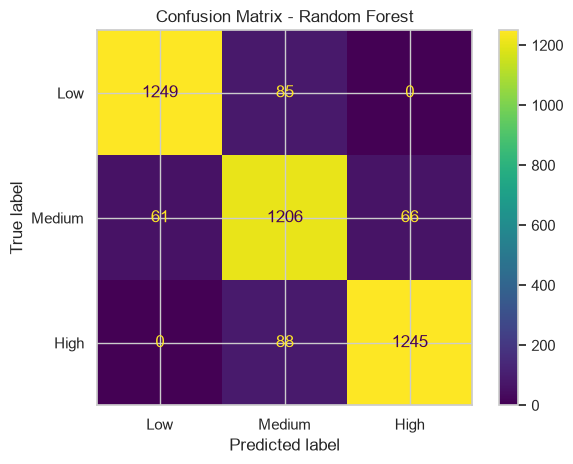


Confusion Matrix - Gradient Boosting
[[1233  101    0]
 [  53 1223   57]
 [   0  109 1224]]


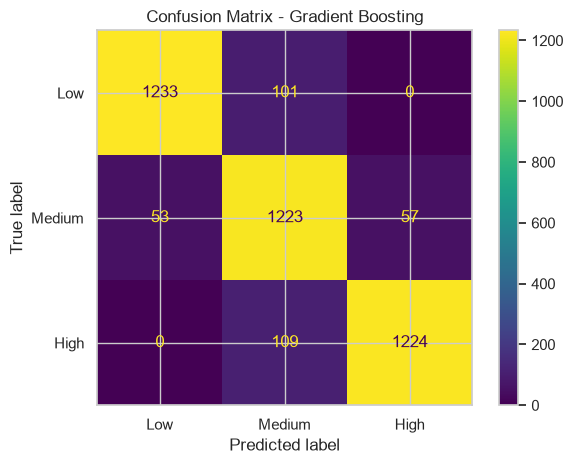


Confusion Matrix - HistGradient Boosting
[[1273   61    0]
 [  30 1262   41]
 [   0   61 1272]]


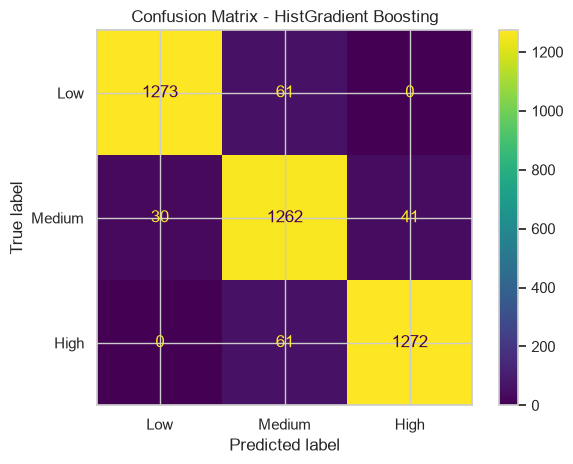

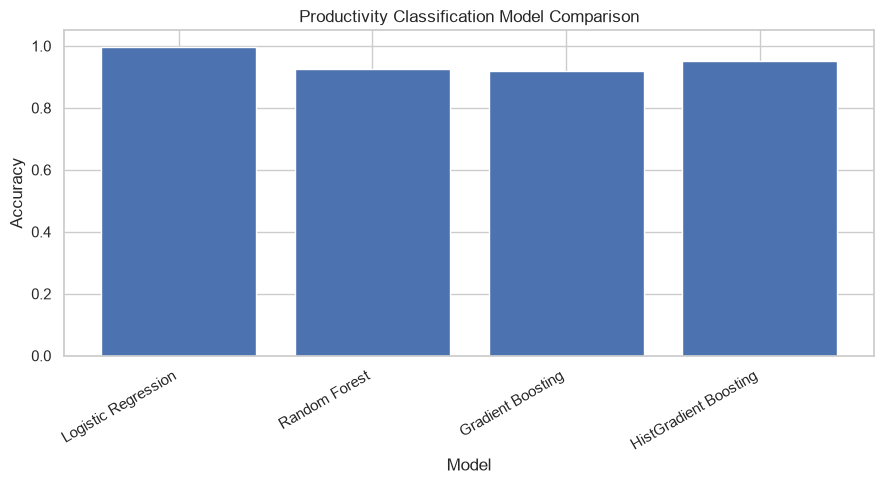

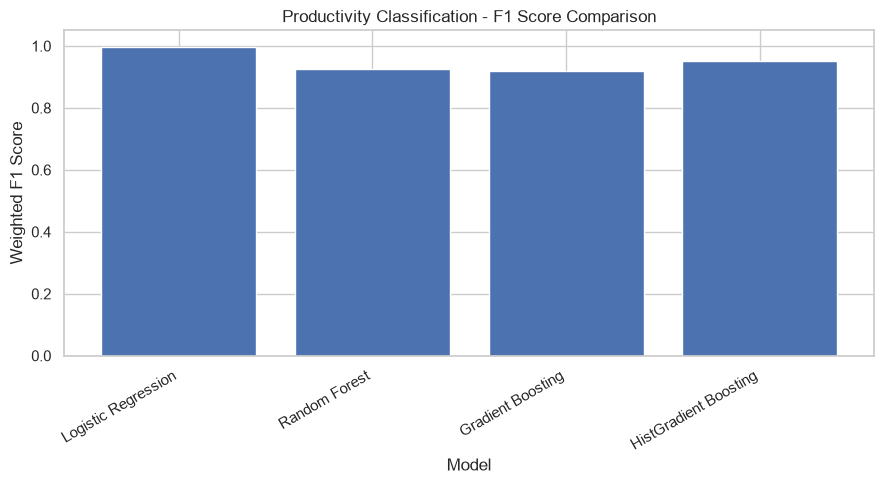


RANDOM FOREST FEATURE IMPORTANCE
              Feature Importance
  study_hours_per_day     0.4093
          focus_score     0.1630
    phone_usage_hours     0.1437
          sleep_hours     0.1434
attendance_percentage     0.0833
         stress_level     0.0573


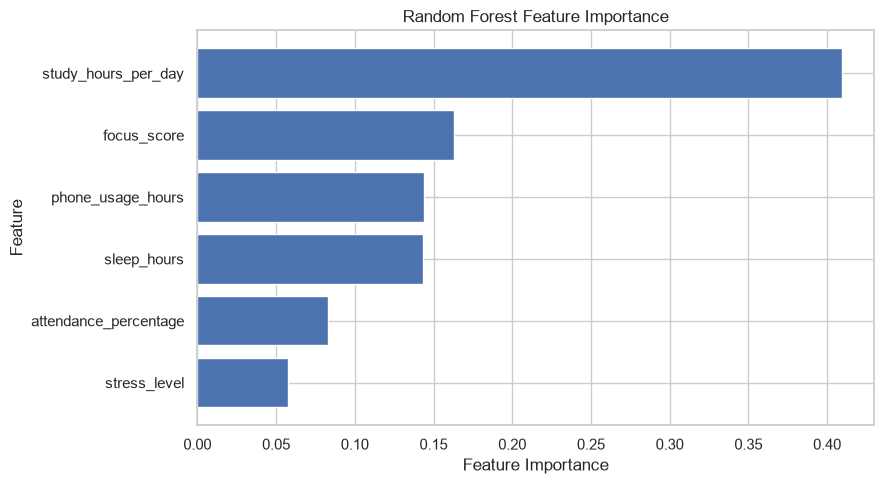


CLASSIFICATION SUMMARY
The numerical productivity score was converted into Low, Medium and High productivity groups using tertiles.

The productivity score itself was excluded from the model inputs to avoid direct target leakage.

Highest F1 Score in this experiment: Logistic Regression
Accuracy: 0.9975
F1 Score: 0.9975

Classification analysis completed successfully.


In [27]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS - V2
# STEP 6: PRODUCTIVITY CLASSIFICATION
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_productivity_distraction.csv"

df = pd.read_csv(DATA_PATH)

# ============================================================
# 1. COPY DATA
# ============================================================

classification_df = df.copy()


# ============================================================
# 2. CREATE PRODUCTIVITY GROUPS
# ============================================================
#
# We use tertiles:
#
# Bottom 1/3  -> Low
# Middle 1/3  -> Medium
# Top 1/3     -> High
#
# IMPORTANT:
# productivity_score is used ONLY to create the labels.
# It will NOT be used as a model feature.
# ============================================================

classification_df["productivity_group"] = pd.qcut(
    classification_df["productivity_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)


# ============================================================
# 3. CHECK CLASS DISTRIBUTION
# ============================================================

print("==============================================")
print("PRODUCTIVITY CLASS DISTRIBUTION")
print("==============================================")

class_counts = (
    classification_df["productivity_group"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

class_percentages = (
    classification_df["productivity_group"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
    * 100
)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

print(class_distribution.to_string(
    formatters={
        "Percentage": "{:.2f}%".format
    }
))


# ============================================================
# 4. DEFINE INPUT FEATURES
# ============================================================
#
# productivity_score is intentionally excluded.
#
# These are the six main variables identified during
# target forensics.
# ============================================================

features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]

X = classification_df[features]

y = classification_df["productivity_group"]


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 6. DEFINE CLASSIFICATION MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "HistGradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}


# ============================================================
# 7. TRAIN AND EVALUATE MODELS
# ============================================================

results = {}

predictions = {}

for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    predictions[model_name] = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }


# ============================================================
# 8. MODEL COMPARISON TABLE
# ============================================================

classification_results = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
)


print("\n==============================================")
print("CLASSIFICATION MODEL RESULTS")
print("==============================================")

print(classification_results.to_string(
    index=False,
    formatters={
        "Accuracy": "{:.4f}".format,
        "Precision": "{:.4f}".format,
        "Recall": "{:.4f}".format,
        "F1 Score": "{:.4f}".format
    }
))


# ============================================================
# 9. CLASSIFICATION REPORTS
# ============================================================

for model_name in models.keys():

    print("\n==============================================")
    print(model_name)
    print("==============================================")

    print(
        classification_report(
            y_test,
            predictions[model_name],
            labels=["Low", "Medium", "High"],
            zero_division=0
        )
    )


# ============================================================
# 10. CONFUSION MATRICES
# ============================================================

for model_name in models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[model_name],
        labels=["Low", "Medium", "High"]
    )

    print(
        f"\nConfusion Matrix - {model_name}"
    )

    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low", "Medium", "High"]
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.title(
    "Productivity Classification Model Comparison"
)

plt.ylim(0, 1.05)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    classification_results["Model"],
    classification_results["F1 Score"]
)

plt.ylabel("Weighted F1 Score")
plt.xlabel("Model")

plt.title(
    "Productivity Classification - F1 Score Comparison"
)

plt.ylim(0, 1.05)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. FEATURE IMPORTANCE - RANDOM FOREST
# ============================================================

rf_model = models["Random Forest"]

rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n==============================================")
print("RANDOM FOREST FEATURE IMPORTANCE")
print("==============================================")

print(rf_importance.to_string(
    index=False,
    formatters={
        "Importance": "{:.4f}".format
    }
))


# ============================================================
# 14. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Random Forest Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

best_model_row = classification_results.loc[
    classification_results["F1 Score"].idxmax()
]

print("\n==============================================")
print("CLASSIFICATION SUMMARY")
print("==============================================")

print(
    "The numerical productivity score was converted "
    "into Low, Medium and High productivity groups "
    "using tertiles."
)

print(
    "\nThe productivity score itself was excluded from "
    "the model inputs to avoid direct target leakage."
)

print(
    f"\nHighest F1 Score in this experiment: "
    f"{best_model_row['Model']}"
)

print(
    f"Accuracy: "
    f"{best_model_row['Accuracy']:.4f}"
)

print(
    f"F1 Score: "
    f"{best_model_row['F1 Score']:.4f}"
)

print(
    "\nClassification analysis completed successfully."
)

INDIVIDUAL STUDENT ANALYSIS
                        Value
study_hours_per_day    9.7200
sleep_hours            6.5900
phone_usage_hours      9.1600
attendance_percentage 67.5500
stress_level           3.0000
focus_score           75.0000

Actual Productivity Group:
High

Predicted Productivity Group:
High

PREDICTION PROBABILITIES
Productivity Group Probability
              High      1.0000
               Low      0.0000
            Medium      0.0000

FEATURE CONTRIBUTIONS TOWARD 'High'
              Feature Student Value Standardized Value Model Coefficient Contribution Absolute Contribution
  study_hours_per_day         9.720              1.628           15.2500      24.8280               24.8280
    phone_usage_hours         9.160              0.881           -6.9290      -6.1067                6.1067
          focus_score        75.000              0.524            8.4304       4.4138                4.4138
         stress_level         3.000             -0.868           -3.9826  

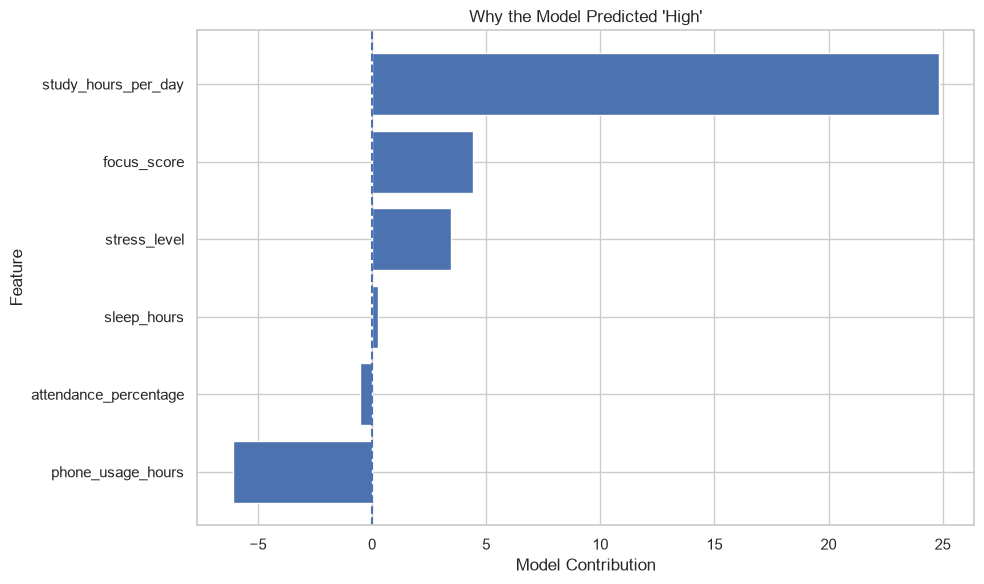


MODEL EXPLANATION
The model classified this student as: High

The strongest model contributions were:
- study_hours_per_day: 24.8280 (toward the 'High' class)
- phone_usage_hours: -6.1067 (away from the 'High' class)
- focus_score: 4.4138 (toward the 'High' class)

IMPORTANT:
These contributions explain how the trained model arrived at its prediction. They should not be interpreted as evidence that changing a particular behavior will cause productivity to increase or decrease.

GLOBAL MODEL COEFFICIENTS
 Class               Feature Coefficient
  High   study_hours_per_day     15.2500
  High           sleep_hours      7.0873
  High     phone_usage_hours     -6.9290
  High attendance_percentage      3.6192
  High          stress_level     -3.9826
  High           focus_score      8.4304
   Low   study_hours_per_day    -15.2317
   Low           sleep_hours     -7.0664
   Low     phone_usage_hours      6.8992
   Low attendance_percentage     -3.6361
   Low          stress_level      3.973

In [28]:
# ============================================================
# DIGITAL WELLBEING ANALYTICS - V2
# STEP 7: EXPLAINABLE AI
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_productivity_distraction.csv"

df = pd.read_csv(DATA_PATH)

# ============================================================
# 1. PREPARE DATA
# ============================================================

explain_df = df.copy()

target = "productivity_score"

features = [
    "study_hours_per_day",
    "sleep_hours",
    "phone_usage_hours",
    "attendance_percentage",
    "stress_level",
    "focus_score"
]


# ============================================================
# 2. CREATE PRODUCTIVITY GROUPS
# ============================================================

explain_df["productivity_group"] = pd.qcut(
    explain_df[target],
    q=3,
    labels=["Low", "Medium", "High"]
)


X = explain_df[features]

y = explain_df["productivity_group"]


# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 4. TRAIN LOGISTIC REGRESSION
# ============================================================

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


model.fit(
    X_train,
    y_train
)


# ============================================================
# 5. SELECT ONE STUDENT
# ============================================================
#
# We use the first student from the test set as an example.
# ============================================================

student = X_test.iloc[[0]]

actual_class = y_test.iloc[0]

predicted_class = model.predict(student)[0]

probabilities = model.predict_proba(student)[0]

classes = model.named_steps[
    "logistic"
].classes_


# ============================================================
# 6. DISPLAY STUDENT INFORMATION
# ============================================================

print("====================================================")
print("INDIVIDUAL STUDENT ANALYSIS")
print("====================================================")

print(student.T.rename(
    columns={student.index[0]: "Value"}
).to_string())


print("\nActual Productivity Group:")
print(actual_class)

print("\nPredicted Productivity Group:")
print(predicted_class)


# ============================================================
# 7. PREDICTION PROBABILITIES
# ============================================================

probability_df = pd.DataFrame({
    "Productivity Group": classes,
    "Probability": probabilities
})


print("\n====================================================")
print("PREDICTION PROBABILITIES")
print("====================================================")

print(probability_df.to_string(
    index=False,
    formatters={
        "Probability": "{:.4f}".format
    }
))


# ============================================================
# 8. GET STANDARDIZED STUDENT VALUES
# ============================================================

scaler = model.named_steps["scaler"]

logistic_model = model.named_steps["logistic"]

student_scaled = scaler.transform(student)


# ============================================================
# 9. CALCULATE FEATURE CONTRIBUTIONS
# ============================================================
#
# For each class:
#
# contribution =
# standardized feature value × logistic coefficient
#
# Positive contribution:
# pushes prediction toward that class.
#
# Negative contribution:
# pushes prediction away from that class.
#
# These are model contributions, NOT causal effects.
# ============================================================

contribution_tables = {}

for class_index, class_name in enumerate(classes):

    coefficients = logistic_model.coef_[class_index]

    contributions = (
        student_scaled[0] *
        coefficients
    )

    contribution_df = pd.DataFrame({
        "Feature": features,
        "Student Value": student.iloc[0].values,
        "Standardized Value": student_scaled[0],
        "Model Coefficient": coefficients,
        "Contribution": contributions
    })

    contribution_df["Absolute Contribution"] = (
        contribution_df["Contribution"].abs()
    )

    contribution_df = contribution_df.sort_values(
        by="Absolute Contribution",
        ascending=False
    )

    contribution_tables[class_name] = contribution_df


# ============================================================
# 10. SHOW CONTRIBUTIONS FOR PREDICTED CLASS
# ============================================================

predicted_contributions = contribution_tables[
    predicted_class
]


print("\n====================================================")
print(
    f"FEATURE CONTRIBUTIONS TOWARD '{predicted_class}'"
)
print("====================================================")

print(predicted_contributions.to_string(
    index=False,
    formatters={
        "Student Value": "{:.3f}".format,
        "Standardized Value": "{:.3f}".format,
        "Model Coefficient": "{:.4f}".format,
        "Contribution": "{:.4f}".format,
        "Absolute Contribution": "{:.4f}".format
    }
))


# ============================================================
# 11. TOP POSITIVE AND NEGATIVE CONTRIBUTORS
# ============================================================

positive_contributions = (
    predicted_contributions[
        predicted_contributions["Contribution"] > 0
    ]
    .sort_values(
        by="Contribution",
        ascending=False
    )
)


negative_contributions = (
    predicted_contributions[
        predicted_contributions["Contribution"] < 0
    ]
    .sort_values(
        by="Contribution"
    )
)


print("\n====================================================")
print("POSITIVE CONTRIBUTORS")
print("====================================================")

print(positive_contributions[
    [
        "Feature",
        "Contribution"
    ]
].to_string(
    index=False,
    formatters={
        "Contribution": "{:.4f}".format
    }
))


print("\n====================================================")
print("NEGATIVE CONTRIBUTORS")
print("====================================================")

print(negative_contributions[
    [
        "Feature",
        "Contribution"
    ]
].to_string(
    index=False,
    formatters={
        "Contribution": "{:.4f}".format
    }
))


# ============================================================
# 12. CONTRIBUTION VISUALIZATION
# ============================================================

plot_df = predicted_contributions.sort_values(
    by="Contribution"
)


plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Contribution"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Model Contribution"
)

plt.ylabel(
    "Feature"
)

plt.title(
    f"Why the Model Predicted '{predicted_class}'"
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. GENERATE SIMPLE TEXT EXPLANATION
# ============================================================

print("\n====================================================")
print("MODEL EXPLANATION")
print("====================================================")

print(
    f"The model classified this student as: "
    f"{predicted_class}"
)

print(
    "\nThe strongest model contributions were:"
)


top_features = predicted_contributions.head(3)

for _, row in top_features.iterrows():

    direction = (
        "toward"
        if row["Contribution"] > 0
        else "away from"
    )

    print(
        f"- {row['Feature']}: "
        f"{row['Contribution']:.4f} "
        f"({direction} the '{predicted_class}' class)"
    )


print(
    "\nIMPORTANT:"
)

print(
    "These contributions explain how the trained model "
    "arrived at its prediction. They should not be interpreted "
    "as evidence that changing a particular behavior will "
    "cause productivity to increase or decrease."
)


# ============================================================
# 14. GLOBAL LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

print("\n====================================================")
print("GLOBAL MODEL COEFFICIENTS")
print("====================================================")

global_coefficients = []

for class_index, class_name in enumerate(classes):

    for feature_index, feature in enumerate(features):

        global_coefficients.append({
            "Class": class_name,
            "Feature": feature,
            "Coefficient": logistic_model.coef_[
                class_index,
                feature_index
            ]
        })


global_coefficients_df = pd.DataFrame(
    global_coefficients
)


print(global_coefficients_df.to_string(
    index=False,
    formatters={
        "Coefficient": "{:.4f}".format
    }
))


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n====================================================")
print("EXPLAINABLE AI SUMMARY")
print("====================================================")

print(
    f"Predicted class: {predicted_class}"
)

print(
    f"Actual class: {actual_class}"
)

print(
    "\nThe contribution analysis shows which input variables "
    "most strongly influenced this individual model prediction."
)

print(
    "\nExplainable AI analysis completed successfully."
)